# Lab 01 — Baselines, Windows and Alerts

An anomaly is not a large number. It is a deviation from an explicit baseline, in context, that
means something operationally. Every detector therefore needs three things, and this lab builds
all three several ways on 30 days of SNMP interface counters:

1. a **baseline** — what does normal mean here, and compared to what?
2. a **score** — how far is this sample from that baseline?
3. a **cutoff** — above which score does anyone get told?

The baseline is where the work is. A fixed line, the whole month's mean, the last few hours,
the same hour last week: each is a different answer to "compared to what", and the window that
defines "the last few hours" turns out to matter as much as the choice of statistic.

## Learning outcomes

1. Separate outlier, anomaly, alert and fault, and name which of the four anomaly types you are
   looking for.
2. Build and compare five baselines: fixed threshold, global z-score, rolling mean, rolling
   median/MAD, and a seasonal baseline.
3. Treat **window size as a hyperparameter** and measure what it costs at both extremes.
4. Take a score through label and alert, with persistence and a maintenance calendar.
5. Report precision, event-level recall, detection delay and alerts per day, then pick a
   threshold as an operations decision rather than a statistical one.

## Step 1 — Libraries and figure settings

Every figure setting in this notebook is made here and nowhere else. No cell below sets a font
size, a line width, a marker size or a colour. Change the type size for a projector by editing
`font.size` once.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy
import scipy.stats as ss
import matplotlib
import matplotlib.pyplot as plt
from cycler import cycler

# One colour means one thing everywhere: blue is the measured signal, orange the baseline or a
# ground-truth window, purple a derived score, red an alert or a limit, green a peer method.
C = {"signal": "#3B7DD8", "baseline": "#E0752D", "score": "#7A5AC7",
     "alert": "#D6455D", "truth": "#FF9F1C", "peer": "#2E9E7B", "muted": "#9AA4B0"}

# The default cycle is the per-port palette, so a plot that draws several ports needs no
# colour argument at all. Distinct hues rather than a gradient: port identity is nominal.
PORT_C = ["#3B7DD8", "#E0752D", "#2E9E7B", "#7A5AC7", "#B04A6E"]

# The three outcomes a single sample can be marked with, one colour and one marker each, fixed
# here so green never means anything but a hit in any figure of this notebook. TN has no entry
# because it is the line itself: it is the overwhelming majority of any month, and marking it
# would bury the three classes that carry the argument.
CONF = {"TP": ("#2E9E7B", "o"), "FP": ("#D6455D", "o"), "FN": ("#7A5AC7", "x")}

# For the figures that draw one curve per (baseline, column): colour carries the baseline and the
# dash pattern carries the column, so nine curves stay readable without nine colours.
BASELINE_C = ["#3B7DD8", "#2E9E7B", "#7A5AC7"]
COLUMN_LS = ["-", "--", ":"]
CONF_LABEL = {"TP": "TP  alert inside an anomaly",
              "FP": "FP  alert outside every anomaly",
              "FN": "FN  anomaly sample, no alert"}

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (14, 4.6),
    "font.size": 14,
    "axes.titlesize": 16, "axes.titlelocation": "left", "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 13, "ytick.labelsize": 13,
    "figure.titlesize": 18,
    "lines.linewidth": 1.4, "lines.markersize": 7,
    "scatter.edgecolors": "white",
    "axes.prop_cycle": cycler(color=PORT_C),
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.autolayout": True,          # every figure is tight_layout by default
})
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)

for m in (np, pd, scipy, matplotlib):
    print(f"{m.__name__:12} {m.__version__}")

numpy        2.4.6
pandas       3.0.3
scipy        1.17.1
matplotlib   3.10.9


## Step 2 — Load the data into `df`

5 ports, one poll every 300 s, 30 days, 43,200 rows. Every counter column is the **total inside
one 5-minute interval**, already differenced by the collector, so there is no cumulative counter
to reset and no negative jump to repair. On a raw SNMP counter that step comes first, and
skipping it is a classic way to manufacture an anomaly out of a device reboot.

`event_label` and `event_id` are ground truth: 10 labelled anomalys, used to score and never to
fit. `change_calendar.csv` says which of them were planned.

In [2]:
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "environments").is_dir():
    ROOT = ROOT.parent                       # find the course root from any launch directory
DATA = ROOT / "data" / "synthetic"

df = pd.read_csv(DATA / "synthetic_rrd_metrics.csv", parse_dates=["timestamp"])
df = df.sort_values(["port_id", "timestamp"]).reset_index(drop=True)

CADENCE = df.groupby("port_id")["timestamp"].diff().dt.total_seconds().median()
# Each counter is the total over a 5-minute bucket, so a sample stamped 11:30 stands for an
# interval, not an instant. Shading a ground-truth window from its first to its last timestamp
# would cover only the bucket centres and leave half a bucket unshaded at each end, which reads
# on screen as the signal rising before the anomaly starts. Every axvspan below is widened by
# HALF so a shaded span covers the samples it contains.
HALF = pd.Timedelta(seconds=CADENCE / 2)
DAY = int(86400 / CADENCE)
DAYS = (df["timestamp"].max() - df["timestamp"].min()).total_seconds() / 86400

print(f"{len(df):,} rows | cadence {CADENCE:.0f}s | {DAY} samples/day | {DAYS:.1f} days")
print(f"duplicate (port, timestamp) keys {df.duplicated(['port_id', 'timestamp']).sum()} | "
      f"missing metric values {df.filter(regex='^[A-Z]').isna().sum().sum()}")
print(df.groupby("port_id")["port_role"].first().to_string())
df.head()

43,200 rows | cadence 300s | 288 samples/day | 30.0 days
duplicate (port, timestamp) keys 0 | missing metric values 0
port_id
port-id7427       wan-primary
port-id7428     wan-secondary
port-id7429     server-uplink
port-id7430       office-vlan
port-id7431    backup-storage


,timestamp,device_id,port_id,port_role,INOCTETS,OUTOCTETS,INERRORS,OUTERRORS,INUCASTPKTS,OUTUCASTPKTS,INNUCASTPKTS,OUTNUCASTPKTS,INDISCARDS,OUTDISCARDS,INUNKNOWNPROTOS,INBROADCASTPKTS,OUTBROADCASTPKTS,INMULTICASTPKTS,OUTMULTICASTPKTS,event_label,event_id
0,2026-02-01 00:00:00,edge-fw-01,port-id7427,wan-primary,2743688.38,1614914.57,0,0,2708,1594,40,37,0,0,0,9,7,5,4,normal,NaN
1,2026-02-01 00:05:00,edge-fw-01,port-id7427,wan-primary,2887409.45,923830.33,0,0,2996,958,37,34,0,0,0,8,6,5,4,normal,NaN
2,2026-02-01 00:10:00,edge-fw-01,port-id7427,wan-primary,3205096.79,1354783.01,0,0,3544,1498,47,43,0,0,0,10,8,6,5,normal,NaN
3,2026-02-01 00:15:00,edge-fw-01,port-id7427,wan-primary,3537524.59,1111387.50,0,0,3690,1159,45,42,0,0,0,10,8,6,5,normal,NaN
4,2026-02-01 00:20:00,edge-fw-01,port-id7427,wan-primary,2550467.43,932305.50,0,0,2566,938,33,30,0,0,0,7,5,4,3,normal,NaN


Raw counters differ by an order of magnitude across ports, so a cutoff meaning one thing on the WAN
uplink means another on the office VLAN. Thirteen features, split into two families by what they
answer: **volume** says how much is moving and **shape** says what the traffic is made of. Shape
features are ratios or a per-packet size, so they are comparable across ports; volume features are
not. Keep the numerator and the denominator too, because a ratio built on three packets is noise.

In [3]:
bytes_all = df["INOCTETS"] + df["OUTOCTETS"]
pkts_all = (df["INUCASTPKTS"] + df["OUTUCASTPKTS"]
            + df["INNUCASTPKTS"] + df["OUTNUCASTPKTS"]
            + df["INBROADCASTPKTS"] + df["OUTBROADCASTPKTS"]
            + df["INMULTICASTPKTS"] + df["OUTMULTICASTPKTS"]).clip(lower=1)

# Five volume features: how much is moving. Absolute, so they are not comparable across ports.
df["traffic_bps"]       = bytes_all * 8 / CADENCE
df["packets_pps"]       = pkts_all / CADENCE
df["errors_pps"]        = (df["INERRORS"] + df["OUTERRORS"]) / CADENCE
df["discards_pps"]      = (df["INDISCARDS"] + df["OUTDISCARDS"]) / CADENCE
df["unknown_proto_pps"] = df["INUNKNOWNPROTOS"] / CADENCE

# Eight shape features: what the traffic is made of. A ratio or a per-packet size, so the same
# cutoff means the same thing on a WAN uplink and on a quiet office VLAN.
df["avg_pkt_bytes"]   = bytes_all / pkts_all
df["broadcast_ratio"] = (df["INBROADCASTPKTS"] + df["OUTBROADCASTPKTS"]) / pkts_all
df["multicast_ratio"] = (df["INMULTICASTPKTS"] + df["OUTMULTICASTPKTS"]) / pkts_all
df["nonucast_ratio"]  = (df["INNUCASTPKTS"] + df["OUTNUCASTPKTS"]) / pkts_all
df["tx_ratio"]        = df["OUTOCTETS"] / bytes_all.clip(lower=1)
df["error_rate"]      = (df["INERRORS"] + df["OUTERRORS"]) / pkts_all
df["discard_rate"]    = (df["INDISCARDS"] + df["OUTDISCARDS"]) / pkts_all
df["err_disc_rate"]   = (df["INERRORS"] + df["OUTERRORS"]
                         + df["INDISCARDS"] + df["OUTDISCARDS"]) / pkts_all

FEATURES = ["traffic_bps", "packets_pps", "errors_pps", "discards_pps", "unknown_proto_pps",
            "avg_pkt_bytes", "broadcast_ratio", "multicast_ratio", "nonucast_ratio",
            "tx_ratio", "error_rate", "discard_rate", "err_disc_rate"]

# One measurement decides which of these any rolling scale can be estimated on. Past half zeros,
# the median is zero and the MAD with it, so the scale collapses onto its floor and every non-zero
# reading divides by something near nothing. Measured here rather than assumed.
zero_fraction = (df[FEATURES] == 0).mean().sort_values()
SCORABLE = [c for c in FEATURES if zero_fraction[c] <= 0.5]
DEGENERATE = [c for c in FEATURES if zero_fraction[c] > 0.5]

display(zero_fraction.rename("zero_fraction").to_frame()
        .assign(verdict=lambda d: np.where(d["zero_fraction"] <= 0.5, "scorable", "degenerate")))
print(f"{len(SCORABLE)} scorable: {SCORABLE}")
print(f"{len(DEGENERATE)} degenerate: {DEGENERATE}")

,zero_fraction,verdict
traffic_bps,0.000000,scorable
packets_pps,0.000000,scorable
avg_pkt_bytes,0.000000,scorable
broadcast_ratio,0.000000,scorable
multicast_ratio,0.000000,scorable
nonucast_ratio,0.000000,scorable
tx_ratio,0.000000,scorable
err_disc_rate,0.890394,degenerate
discards_pps,0.912917,degenerate
discard_rate,0.912917,degenerate


7 scorable: ['traffic_bps', 'packets_pps', 'avg_pkt_bytes', 'broadcast_ratio', 'multicast_ratio', 'nonucast_ratio', 'tx_ratio']
6 degenerate: ['errors_pps', 'discards_pps', 'unknown_proto_pps', 'error_rate', 'discard_rate', 'err_disc_rate']


Six of the thirteen are degenerate, and they are exactly the ones an engineer would reach for
first: errors, discards, unknown protocols. `errors_pps` and `error_rate` are zero in 97.6% of
samples, `unknown_proto_pps` in 99.0%.

That is not a reason to drop them. It is a reason to score them differently, and Step 6 shows the
method that suits a column whose normal value is a true zero. Every rolling or seasonal baseline
from Step 9 onward runs on the seven scorable features only, and Lab 02 shows what happens when the
degenerate six are fed to a scoring rule that assumes dispersion.

In [4]:
df.loc[df["event_label"] != "normal", "event_label"].value_counts()

event_label
multicast_flooding           90
broadcast_storm              60
large_file_backup            36
business_traffic_growth      24
load_sensitive_link_issue    18
abnormal_device_sender       16
queue_congestion             14
small_packet_scan            10
unknown_protocol_scan        10
link_quality_issue            8
Name: count, dtype: int64

## Step 3 — Four words that are not synonyms

Most alert fatigue starts with these four being used interchangeably.

| term | what it means | must it page someone? |
|---|---|---|
| **outlier** | far from the rest of the distribution | no, it may be an ordinary peak |
| **anomaly** | does not match expected behaviour for this context | no, it may be an early symptom |
| **alert** | a notification the system actually sent | it is already in someone's queue |
| **fault / incident** | function or users are affected | usually yes |

The goal is not to notify a human about everything unusual. It is to surface what is worth
acting on earlier, more accurately, and with less noise.

### The four shapes an anomaly takes

| type | shape | example in this dataset |
|---|---|---|
| **point** | one sample far from everything | a single scrape spike |
| **contextual** | ordinary value, wrong context | event C, a bulk transfer at 01:00 |
| **collective** | each sample normal, the run is not | event G, a sustained broadcast storm |
| **change point** | the level moves and stays there | the weekday-to-weekend transition |

Naming the type first decides the method. A point anomaly needs a per-sample cutoff, a
collective one needs a persistence rule, a change point needs a before-and-after comparison.

The change-point row is deliberately not an event from the catalogue. `change_calendar.csv`
describes CH-02 as a permanent level shift, but measuring the weekday 09:00-11:00 mean week by
week on `port-id7430` gives 8.2e5, 6.9e5, 7.1e5, 8.6e5, 6.8e5: noise, not a step. The only
genuine, repeated level change in this month is the weekend, and it is not an incident. Lab 02
returns to that.

### Where a baseline comes from

| source | example |
|---|---|
| physical or capacity limit | interface line rate, disk capacity |
| SLO or SLA | p95 latency, availability, error budget |
| expert knowledge | this device's error counters should sit near zero |
| recent history | the last hour on this port |
| same seasonal position | this Monday 10:00 against previous Mondays at 10:00 |
| peer group | the other switch ports in this rack |
| upstream / downstream | did CPU rise when requests rose? |

This lab works through the middle three, which are the ones the data can answer on its own.

## Step 4 — What is available, and what this run uses

The first cell inventories the data: which ports exist, what each is for, how many labelled anomaly
windows sit on it, and which columns can be scored. The second cell is the only place a choice is
made. Three lists and three numbers, and everything below loops over the lists, so adding an entry
adds a panel and a table row.

`PORTS` defaults to every port, because a detector runs on the whole fleet and drawing only the
port that had the event hides the alerts it raised on the other four. Those are what
`alerts_per_day` is made of. Narrow it to one or two ports when you want to read individual
samples.

In [5]:
RAW = [c for c in df.columns if c.isupper()]

inventory = (df.assign(labelled=df["event_label"] != "normal")
             .groupby(["device_id", "port_id", "port_role"], as_index=False)
             .agg(samples=("timestamp", "size"), event_samples=("labelled", "sum"),
                  anomaly_windows=("event_id", "nunique")))
display(inventory)

print("scorable features (a rolling scale can be estimated on these):")
print("   ", ", ".join(SCORABLE))
print("degenerate features (over half zeros; Step 6 shows what suits them):")
print("   ", ", ".join(DEGENERATE))
print(f"raw counter columns ({len(RAW)}, per-interval totals):")
print("   ", ", ".join(RAW))
print("event types:")
print("   ", ", ".join(sorted(df.loc[df['event_label'] != 'normal', 'event_label'].unique())))

,device_id,port_id,port_role,samples,event_samples,anomaly_windows
0,core-sw-01,port-id7429,server-uplink,8640,38,3
1,core-sw-01,port-id7430,office-vlan,8640,70,4
2,dist-sw-02,port-id7431,backup-storage,8640,66,3
3,edge-fw-01,port-id7427,wan-primary,8640,62,4
4,edge-fw-01,port-id7428,wan-secondary,8640,50,4


scorable features (a rolling scale can be estimated on these):
    traffic_bps, packets_pps, avg_pkt_bytes, broadcast_ratio, multicast_ratio, nonucast_ratio, tx_ratio
degenerate features (over half zeros; Step 6 shows what suits them):
    errors_pps, discards_pps, unknown_proto_pps, error_rate, discard_rate, err_disc_rate
raw counter columns (15, per-interval totals):
    INOCTETS, OUTOCTETS, INERRORS, OUTERRORS, INUCASTPKTS, OUTUCASTPKTS, INNUCASTPKTS, OUTNUCASTPKTS, INDISCARDS, OUTDISCARDS, INUNKNOWNPROTOS, INBROADCASTPKTS, OUTBROADCASTPKTS, INMULTICASTPKTS, OUTMULTICASTPKTS
event types:
    abnormal_device_sender, broadcast_storm, business_traffic_growth, large_file_backup, link_quality_issue, load_sensitive_link_issue, multicast_flooding, queue_congestion, small_packet_scan, unknown_protocol_scan


In [6]:
# ---- the only place these are chosen ------------------------------------------------
PORTS = sorted(df["port_id"].unique())                        # the whole fleet
COLUMNS = ["traffic_bps", "broadcast_ratio", "multicast_ratio"]
ANOMALY_TYPES = ["broadcast_storm", "multicast_flooding"]       # what the figures zoom to

THRESHOLD = 4.0        # score above which a sample breaches
N_CONSEC = 2           # breaches in a row before a breach becomes a label (Step 11)
WINDOW = 144           # rolling-baseline length in samples, 12 h. Step 9 is about this number
# --------------------------------------------------------------------------------------

print(f"{len(PORTS)} ports | {len(COLUMNS)} columns | window {WINDOW} samples = "
      f"{WINDOW * CADENCE / 3600:.0f} h | threshold {THRESHOLD} | confirm {N_CONSEC} in a row")
n_win = df[df["event_label"] != "normal"].groupby(["event_id", "port_id"]).ngroups
print(f"{n_win} anomaly windows across those ports, "
      f"{df['event_label'].isin(ANOMALY_TYPES).sum()} samples of type {ANOMALY_TYPES}")

5 ports | 3 columns | window 144 samples = 12 h | threshold 4.0 | confirm 2 in a row
18 anomaly windows across those ports, 150 samples of type ['broadcast_storm', 'multicast_flooding']


## Step 5 — Tools

`anomaly_windows` gives ground truth, `plot_signals` draws signals with events, baselines and
alerts, `plot_ranked` shows scores against a cutoff, and `report` scores detectors on the four
numbers operations actually reads.

`plot_signals(outcomes=True)` is worth knowing about before the first figure. It stops marking
alerts in one colour and splits every sample into three classes, with the counts in each panel
title:

| marker | class | meaning |
|---|---|---|
| green circle | **TP** | alerted, and inside an anomaly window |
| red circle | **FP** | alerted, outside every anomaly window |
| purple cross | **FN** | inside an anomaly window, no alert |

The fourth class, TN, is the line itself. It is the overwhelming majority of any month, so
marking it would bury the three that carry the argument. The positive/negative rule is the one
`report` uses, so a green dot in a figure is a sample counted in that table's `precision`.

In [7]:
def anomaly_windows(data=None, events=None, ports=None):
    """Ground-truth (start, end) per anomaly and port. Pass "all" to drop a filter."""
    data = df if data is None else data
    events = ANOMALY_TYPES if events is None else events
    ports = PORTS if ports is None else ports
    w = data[data["event_label"] != "normal"]
    if events != "all":
        w = w[w["event_label"].isin(events)]
    if ports != "all":
        w = w[w["port_id"].isin(ports)]
    return (w.groupby(["event_id", "event_label", "port_id"], as_index=False)
             .agg(start=("timestamp", "min"), end=("timestamp", "max"), n=("timestamp", "size"))
             .rename(columns={"event_label": "event_type"})
             .sort_values("start").reset_index(drop=True))


def plot_signals(data=None, columns=None, ports=None, events=None, alerts=None,
                 baselines=None, outcomes=False, pad="6h", title=None, zoom=False):
    """One panel per column, one line per port, ground truth shaded, alerts marked.

    `alerts` and `baselines` are each a Series or a dict {column: Series}. Drawing the baseline
    over the signal is the only way to see a rolling baseline being dragged upward by the event
    it is supposed to be judging.

    outcomes=False marks every alert the same way, which answers "where did it fire".
    outcomes=True
    splits each sample into TP, FP or FN and prints the counts in the panel title, which answers
    "was it right". A sample is positive when it falls inside an anomaly window on that port, on
    exactly the accounting `report` uses, so the figure and the table never disagree. TN is the
    line itself and is not marked.

    The x-range is the whole month by default, which is where stray alerts away from any event
    are visible. zoom=True narrows it to the events in `events` plus `pad`, for the figures whose
    argument depends on seeing individual samples.
    """
    data = df if data is None else data
    columns = COLUMNS if columns is None else columns
    ports = PORTS if ports is None else ports
    events = ANOMALY_TYPES if events is None else events

    t0, t1 = data["timestamp"].min(), data["timestamp"].max()
    # `events` chooses what to zoom to; the shading always covers every anomaly window on the
    # drawn ports. Shading only the selected types would leave a red dot sitting on blank
    # background that `report` had already counted as a true positive.
    zoom_to = anomaly_windows(data, events, ports)
    win = anomaly_windows(data, "all", ports)
    if zoom and len(zoom_to) and events != "all":
        pad = pd.Timedelta(pad)
        t0, t1 = zoom_to["start"].min() - pad, zoom_to["end"].max() + pad
    spread = lambda x: None if x is None else (x if isinstance(x, dict)
                                               else {c: x for c in columns})
    alerts, baselines = spread(alerts), spread(baselines)
    tally = {c: {"TP": 0, "FP": 0, "FN": 0} for c in columns}

    h = plt.rcParams["figure.figsize"][1] * 0.72
    fig, axes = plt.subplots(len(columns), 1, figsize=(plt.rcParams["figure.figsize"][0],
                                                       h * len(columns)),
                             sharex=True, squeeze=False)
    for ax, col in zip(axes[:, 0], columns):
        for k, pid in enumerate(ports):
            g = data.loc[(data["port_id"] == pid) & data["timestamp"].between(t0, t1)]
            # Markers on a short view, because a line between two samples crosses the window
            # edge and makes the signal look as if it moved before the event did.
            ax.plot(g["timestamp"], g[col], marker="." if len(g) <= 300 else None,
                    label=pid[-4:])
            if baselines is not None and col in baselines:
                ax.plot(g["timestamp"], baselines[col].loc[g.index], ls="--",
                        color=C["baseline"])
            if alerts is not None and col in alerts:
                fired = alerts[col].loc[g.index].fillna(False).to_numpy()
                if not outcomes:
                    ax.scatter(g.loc[fired, "timestamp"], g.loc[fired, col],
                               color=C["alert"], zorder=5)
                    continue
                # positive means inside an anomaly window on this port, the same rule report uses
                pos = np.zeros(len(g), bool)
                for e in win[win["port_id"] == pid].itertuples():
                    pos |= g["timestamp"].between(e.start, e.end).to_numpy()
                for kind, m in (("TP", fired & pos), ("FP", fired & ~pos),
                                ("FN", ~fired & pos)):
                    colour, marker = CONF[kind]
                    ax.plot(g.loc[m, "timestamp"], g.loc[m, col], linestyle="none",
                            marker=marker, color=colour, zorder=5)
                    tally[col][kind] += int(m.sum())
        for e in win.itertuples():
            ax.axvspan(max(e.start - HALF, t0), min(e.end + HALF, t1),
                       color=C["truth"], alpha=0.25, lw=0)
        ax.set_ylabel(col)
        if outcomes and alerts is not None and col in alerts:
            ax.set_title("  ".join(f"{k} {v}" for k, v in tally[col].items()))

    axes[0, 0].axvspan(t0, t0, color=C["truth"], alpha=0.25, lw=0, label="anomaly (ground truth)")
    if baselines is not None:
        axes[0, 0].plot([], [], ls="--", color=C["baseline"], label="baseline")
    if alerts is not None and outcomes:
        for kind, (colour, marker) in CONF.items():
            axes[0, 0].plot([], [], linestyle="none", marker=marker, color=colour,
                            label=CONF_LABEL[kind])
    elif alerts is not None:
        axes[0, 0].scatter([], [], color=C["alert"], label="alert")
    # Headroom so the shared legend never sits on top of an alert marker.
    lo, hi = axes[0, 0].get_ylim()
    axes[0, 0].set_ylim(lo, hi + 0.42 * (hi - lo))
    axes[0, 0].legend(ncol=3 if outcomes else len(ports) + 3, loc="upper left",
                      framealpha=0.9)
    axes[-1, 0].set_xlim(t0, t1)
    axes[-1, 0].tick_params(axis="x", labelrotation=20)
    fig.suptitle(title or f"{', '.join(ports)}  |  {events}")
    plt.show()


def plot_ranked(score, threshold=None, name="score", ax=None):
    """Scores sorted high to low with the cutoff drawn across them.

    A cutoff sitting in a gap survives being moved. One inside a dense band splits
    near-identical samples on nothing.
    """
    threshold = THRESHOLD if threshold is None else threshold
    s = pd.Series(score).dropna().sort_values(ascending=False).to_numpy()
    over = s > threshold
    rank = np.arange(1, len(s) + 1)
    own = ax is None
    if own:
        _, ax = plt.subplots()
    ax.plot(rank[~over], s[~over], "o", color=C["signal"], label="normal")
    ax.plot(rank[over], s[over], "o", color=C["alert"], label=f"anomaly ({over.sum()})")
    ax.axhline(threshold, color=C["alert"], ls="--", label=f"cutoff {threshold:g}")
    ax.set(xscale="log", xlabel="rank (log)", ylabel=name, title=name)
    ax.legend()
    if own:
        plt.show()


def report(alerts, data=None, ports=None, events="all"):
    """One row per detector, on the numbers a duty roster is actually built from.

    precision       share of alerts that landed inside an anomaly window
    anomaly_recall    windows with at least one alert inside them, over all windows. An incident
                    lasting an hour does not need every minute flagged, only one.
    delay_min       median minutes from a window's start to its first alert
    alerts_per_day  alerts outside every anomaly window, divided by the days on record

    Accuracy is deliberately absent: with 226 anomaly samples in 43,200, alerting on nothing
    scores over 99%.
    """
    data = df if data is None else data
    ports = PORTS if ports is None else ports
    sub = data[data["port_id"].isin(ports)] if ports != "all" else data
    win = anomaly_windows(sub, events, ports)
    inside = np.zeros(len(sub), bool)
    for e in win.itertuples():
        inside |= ((sub["port_id"] == e.port_id)
                   & sub["timestamp"].between(e.start, e.end)).to_numpy()

    rows = []
    for name, a in alerts.items():
        a = a.loc[sub.index].fillna(False).to_numpy()
        caught, delays = 0, []
        for e in win.itertuples():
            m = ((sub["port_id"] == e.port_id)
                 & sub["timestamp"].between(e.start, e.end)).to_numpy()
            if (a & m).any():
                caught += 1
                delays.append((sub.loc[a & m, "timestamp"].min() - e.start).total_seconds() / 60)
        rows.append({"detector": name, "alerts": int(a.sum()),
                     "precision": round(float((a & inside).sum() / a.sum()), 3) if a.sum() else np.nan,
                     "anomaly_recall": f"{caught}/{len(win)}",
                     "delay_min": round(float(np.median(delays)), 1) if delays else np.nan,
                     "alerts_per_day": round(float((a & ~inside).sum()) / DAYS, 2)})
    return pd.DataFrame(rows)


def confirm(breach, data=None, n=None):
    """A breach becomes a label only after n of them in a row on the same port."""
    data = df if data is None else data
    n = N_CONSEC if n is None else n
    label = breach.fillna(False)
    for k in range(1, n):
        label &= breach.groupby(data["port_id"]).shift(k).fillna(False)
    return label

Look at the data before modelling it.

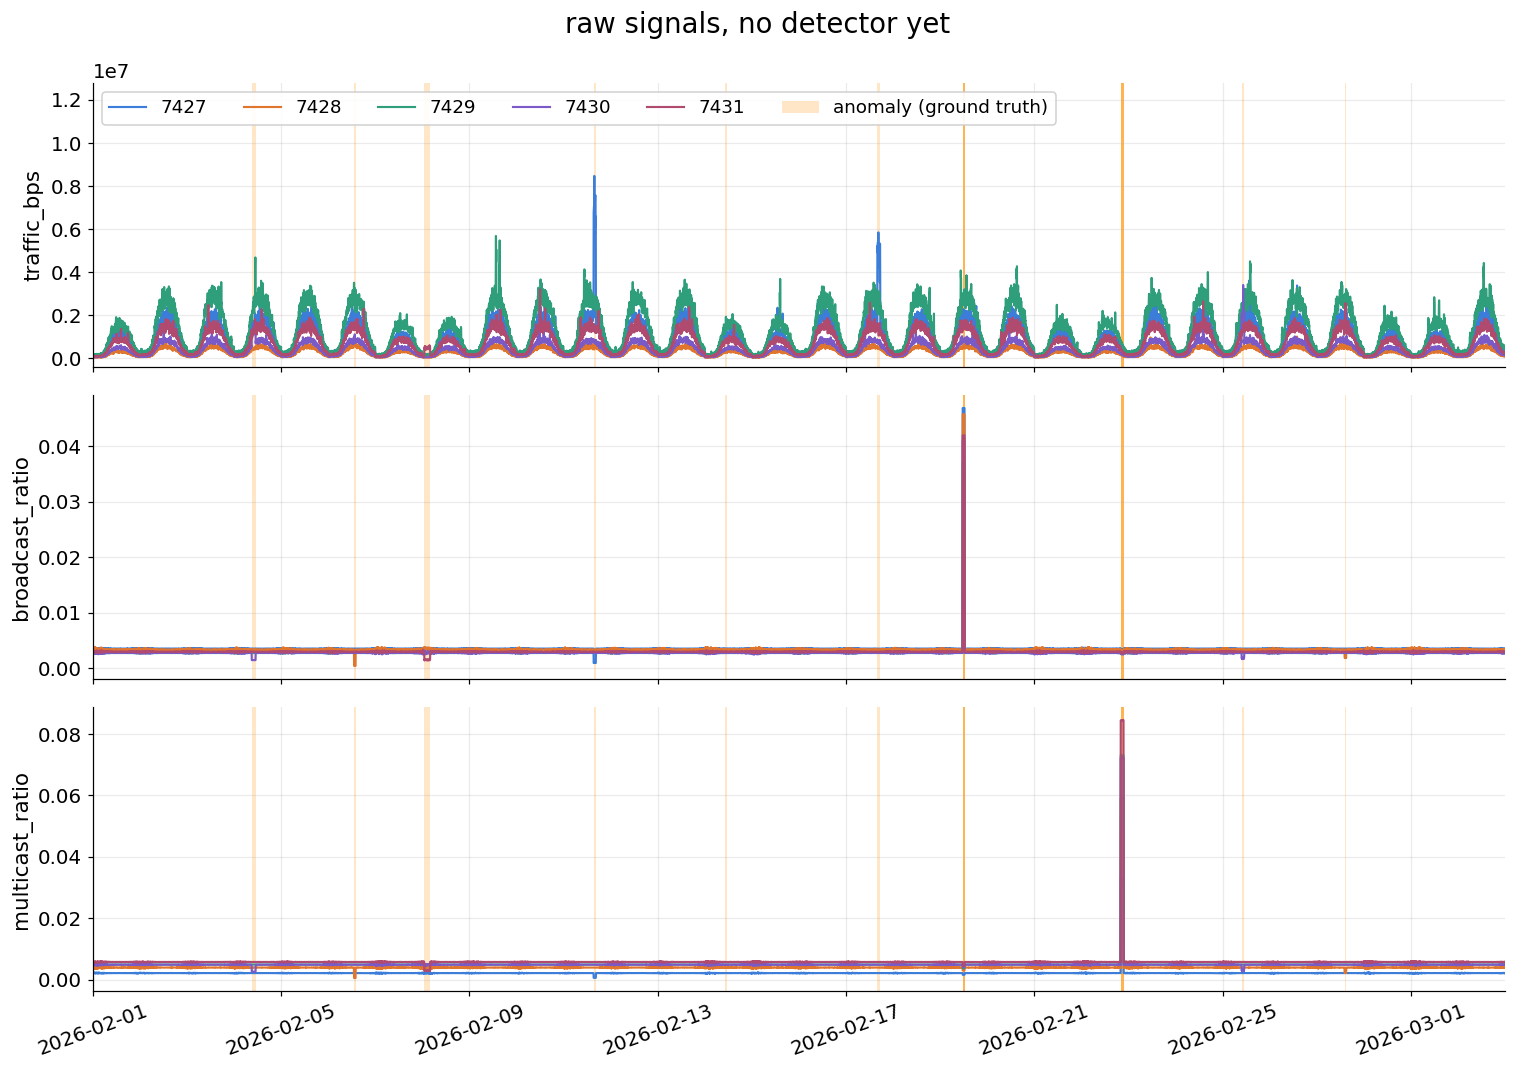

In [8]:
plot_signals(data=df, columns=COLUMNS, ports=PORTS, events=ANOMALY_TYPES,
             alerts=None, baselines=None, outcomes=False, pad="6h", zoom=False,
             title="raw signals, no detector yet")

The storm and the flooding are obvious on the ratio columns and invisible on `traffic_bps`: they
change the packet **mix**, not the volume. Both hit every port at the same minute, which is what
an L2 problem looks like. The signal you score decides what you can detect, before any statistics
happen.

## Step 6 — Baseline 1: a fixed threshold

The simplest baseline and still the most deployed. A constant from a spec, an SLO or an engineer's
judgement. It ignores every cycle and adapts to nothing, which is exactly why it keeps working when
the clever methods break, and why it is the right fallback layer under them.

Write it as `score = value / limit` rather than `value > limit`. Then 1.0 always means "at the
limit", scores are comparable across columns whose units differ, and the threshold documents itself
instead of living in a config file three directories away.

A fixed rule is correct when two preconditions hold, and both are checkable:

1. **The reference point is physical.** Zero errors is a true zero, not a low reading. No such point
   exists on `traffic_bps`, where zero means the link is down.
2. **There is an order-of-magnitude gap** between ordinary background and a real fault, so the limit
   sits in empty space and moving it a little changes nothing.

`errors_pps` satisfies both. Measure the gap before choosing the line.

In [9]:
col = "errors_pps"
quiet = df.loc[df["event_label"] == "normal", col]
print(f"{col}: highest reading outside any anomaly {quiet.max():.4f}")
for eid, g in df[df["event_label"] != "normal"].groupby("event_id"):
    print(f"   {eid}  {g['event_label'].iloc[0]:26} peak {df.loc[g.index, col].max():.4f}")

errors_pps: highest reading outside any anomaly 0.0100
   A  business_traffic_growth    peak 0.0033
   B  small_packet_scan          peak 0.0000
   C  large_file_backup          peak 0.0000
   D  queue_congestion           peak 0.0000
   E  link_quality_issue         peak 1.9167
   F  load_sensitive_link_issue  peak 1.7967
   G  broadcast_storm            peak 0.0033
   H  multicast_flooding         peak 0.0000
   I  abnormal_device_sender     peak 0.0000
   J  unknown_protocol_scan      peak 0.0000


The gap is two decades wide: 0.0100 is the worst ordinary reading, and events E and F peak at 1.7967
and 1.9167. A limit anywhere between them works, so `0.05` is a defensible choice rather than a
tuned one.

Note the other side of it. Eight of the ten anomaly types leave `errors_pps` at exactly zero. A
fixed rule on the right column is the best method in this lab and a hopeless general policy, and
those two statements are the same statement.

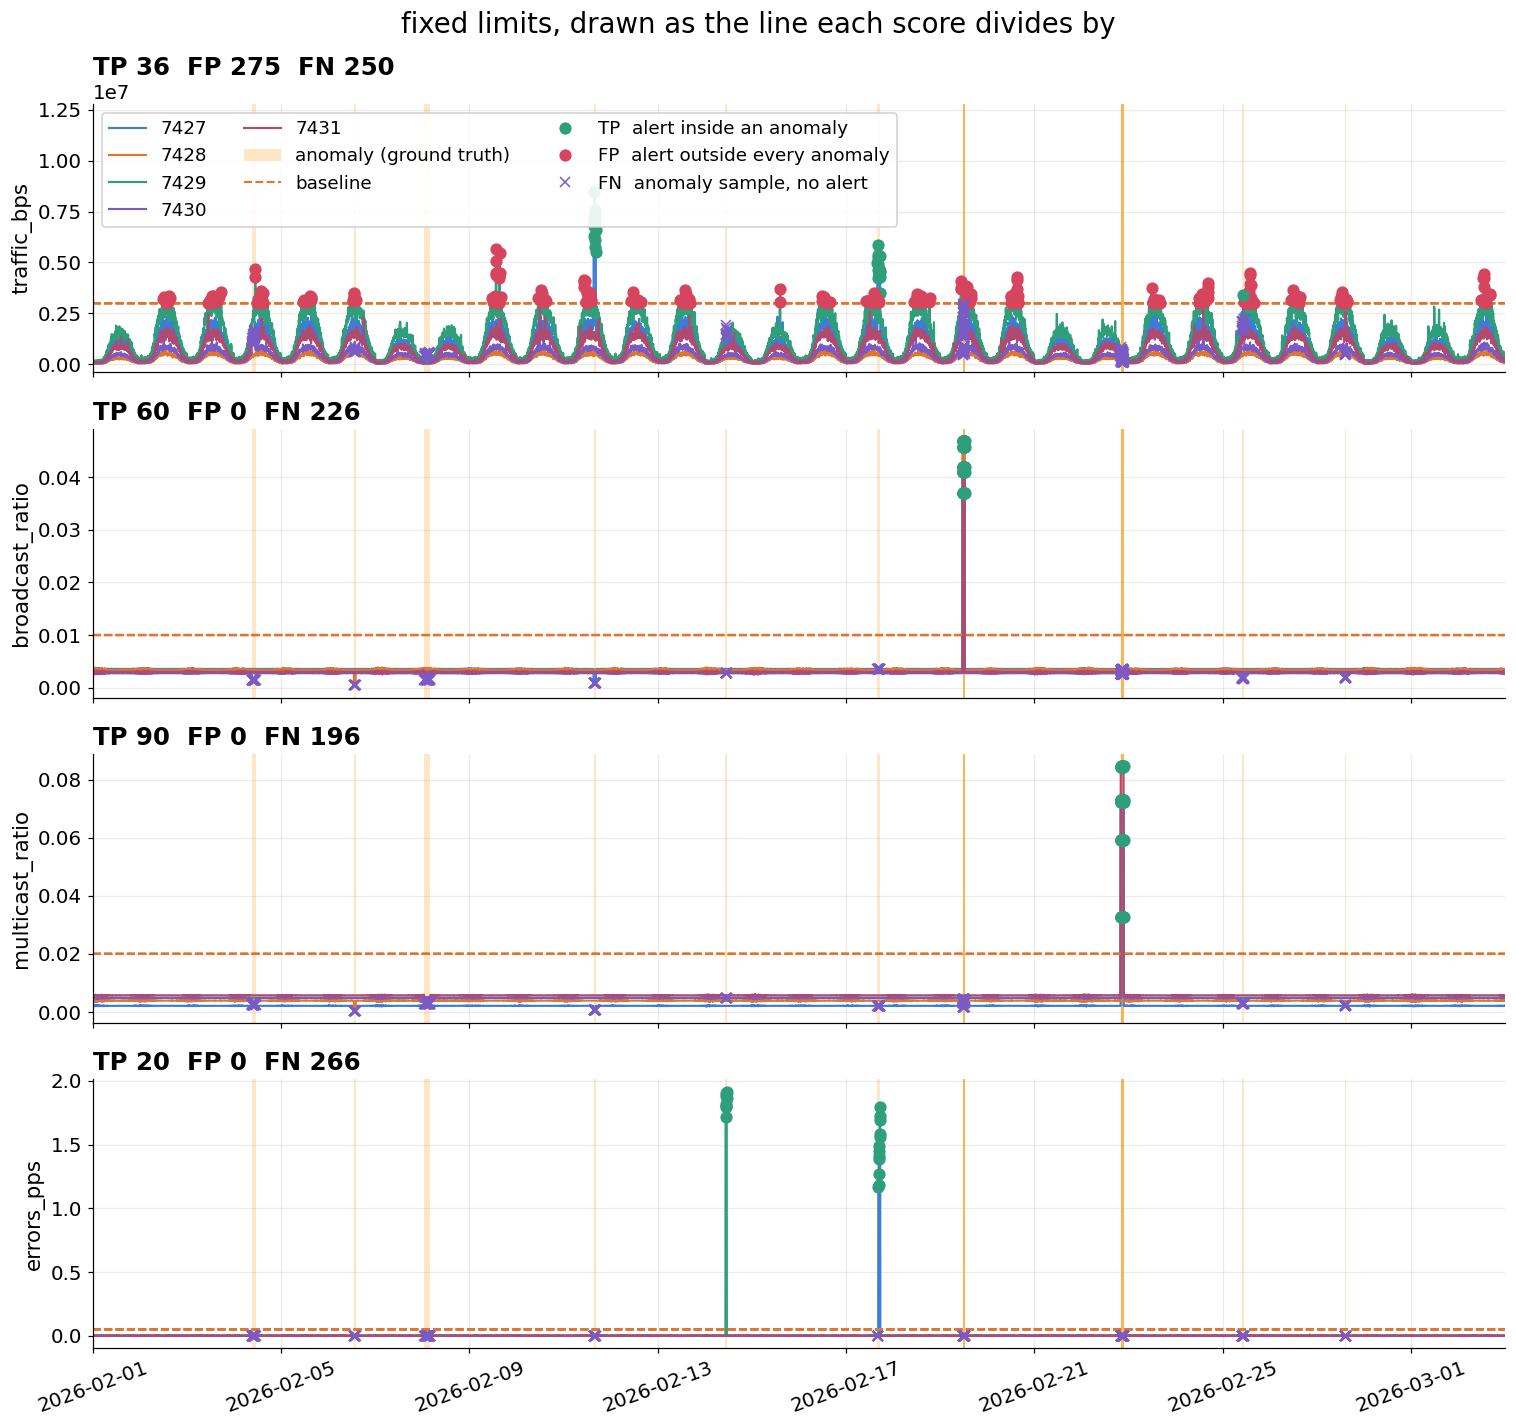

,detector,alerts,precision,anomaly_recall,delay_min,alerts_per_day
0,fixed traffic_bps > 3e+06,311,0.116,4/18,10.0,9.17
1,fixed broadcast_ratio > 0.01,60,1.000,5/18,0.0,0.00
2,fixed multicast_ratio > 0.02,90,1.000,5/18,0.0,0.00
3,fixed errors_pps > 0.05,20,1.000,2/18,15.0,0.00


In [10]:
# One limit per feature. Edit these on site: every one is somebody's judgement, not a fitted value.
LIMITS = {"traffic_bps": 3.0e6, "packets_pps": 4.0e3, "errors_pps": 0.05,
          "discards_pps": 0.05, "unknown_proto_pps": 0.02, "avg_pkt_bytes": 1400.0,
          "broadcast_ratio": 0.01, "multicast_ratio": 0.02, "nonucast_ratio": 0.05,
          "tx_ratio": 0.9, "error_rate": 1e-4, "discard_rate": 1e-4, "err_disc_rate": 2e-4}


def fixed_score(data=df, col="traffic_bps", limit=None):
    """value / limit, so 1.0 is the limit on every column whatever its unit."""
    limit = LIMITS[col] if limit is None else limit
    return data[col] / limit


# The configured columns plus errors_pps, so the contrast sits in one table.
FIXED_COLS = COLUMNS + ["errors_pps"]
alerts_fixed = {c: fixed_score(data=df, col=c, limit=LIMITS[c]) > 1.0 for c in FIXED_COLS}

plot_signals(data=df, columns=FIXED_COLS, ports=PORTS, events=ANOMALY_TYPES,
             alerts=alerts_fixed, outcomes=True, zoom=False,
             baselines={c: pd.Series(LIMITS[c], index=df.index) for c in FIXED_COLS},
             title="fixed limits, drawn as the line each score divides by")
report(alerts={f"fixed {c} > {LIMITS[c]:g}": a for c, a in alerts_fixed.items()},
       data=df, ports=PORTS, events="all")

Three outcomes in one table, and they are the three cases a fixed rule has.

`errors_pps` is the precondition case: a physical zero and a two-decade gap, so the rule is exact,
and it is the only detector in this lab that finds event E.

The ratio columns are the tolerable case. They sit in a narrow band and the anomalies leave it, so a
hand-picked line works even though nothing physical anchors it.

`traffic_bps` is the failure case. The line is either above the daily peak, so it never fires, or
below it, so it fires every afternoon; no constant is both, and the precision column says which side
of that choice this limit landed on.

Every remaining baseline in this lab exists to answer that third case. None of them improves on the
first.

## Step 7 — Baseline 2: the global z-score

$$z_i = (x_i - \bar{x}) / \sigma$$

The baseline is now the month's own mean, and the score says how many standard deviations out a
sample sits. Computed **per port**, because a busy uplink would otherwise define normal for a
quiet VLAN.

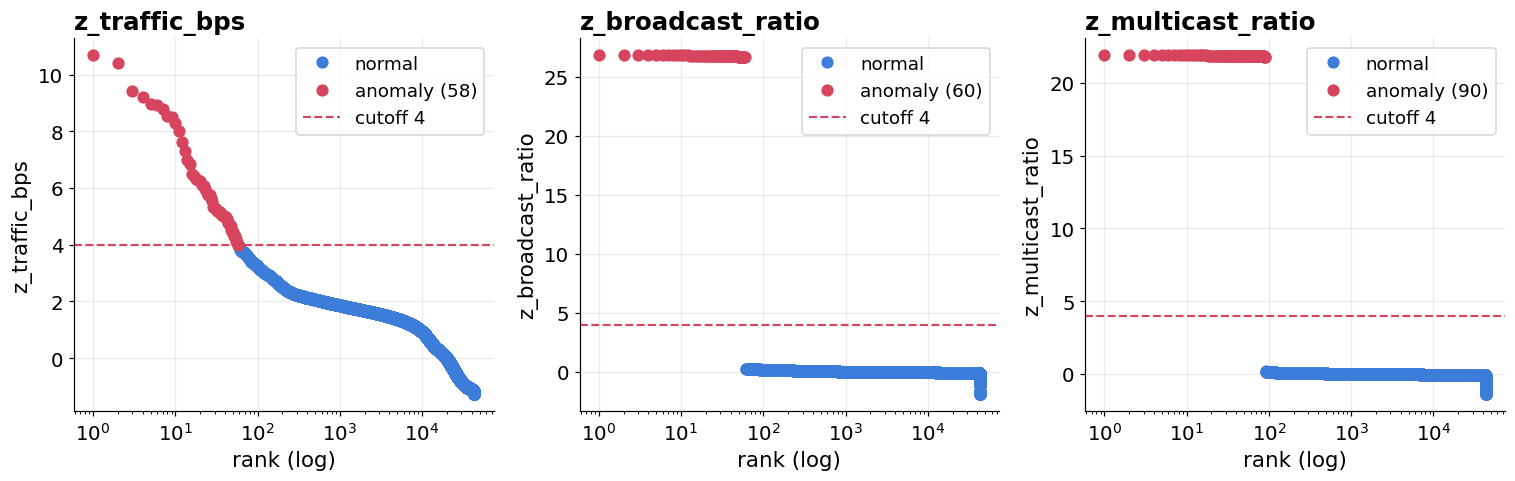

In [11]:
def modified_zscore(x, k=1.4826):
    """(x - median) / (k * MAD), NaN everywhere if the MAD is zero.

    k rescales the MAD to read on the same axis as a standard deviation on normal data. A zero
    MAD means over half the samples are identical, and no rescaling saves a scale of zero, so
    the function refuses rather than dividing.
    """
    x = np.asarray(x, dtype=float)
    d = x - np.median(x)
    mad = np.median(np.abs(d))
    return d / (k * mad) if mad > 0 else np.full_like(x, np.nan)


def add_scores(data, columns=None, ports=None, kind="z"):
    """Write one whole-history score column per signal, computed within each port."""
    columns = COLUMNS if columns is None else columns
    ports = PORTS if ports is None else ports
    for col in columns:
        out = f"{kind}_{col}"
        data[out] = np.nan
        for pid in (data["port_id"].unique() if ports == "all" else ports):
            m = data["port_id"] == pid
            v = data.loc[m, col].to_numpy(dtype=float)
            data.loc[m, out] = ss.zscore(v, ddof=0) if kind == "z" else modified_zscore(v)


add_scores(data=df, columns=COLUMNS, ports=PORTS, kind="z")

w, h = plt.rcParams["figure.figsize"]
fig, axes = plt.subplots(1, len(COLUMNS), figsize=(w, h), squeeze=False)
for ax, col in zip(axes[0], COLUMNS):
    plot_ranked(score=df.loc[df["port_id"].isin(PORTS), f"z_{col}"],
                threshold=THRESHOLD, name=f"z_{col}", ax=ax)
plt.show()

The ratio columns put a handful of points far above a flat body, so a cutoff at 4 lands in empty
space and moving it changes nothing. `traffic_bps` descends smoothly through the cutoff, so every
point near the line is a coin toss.

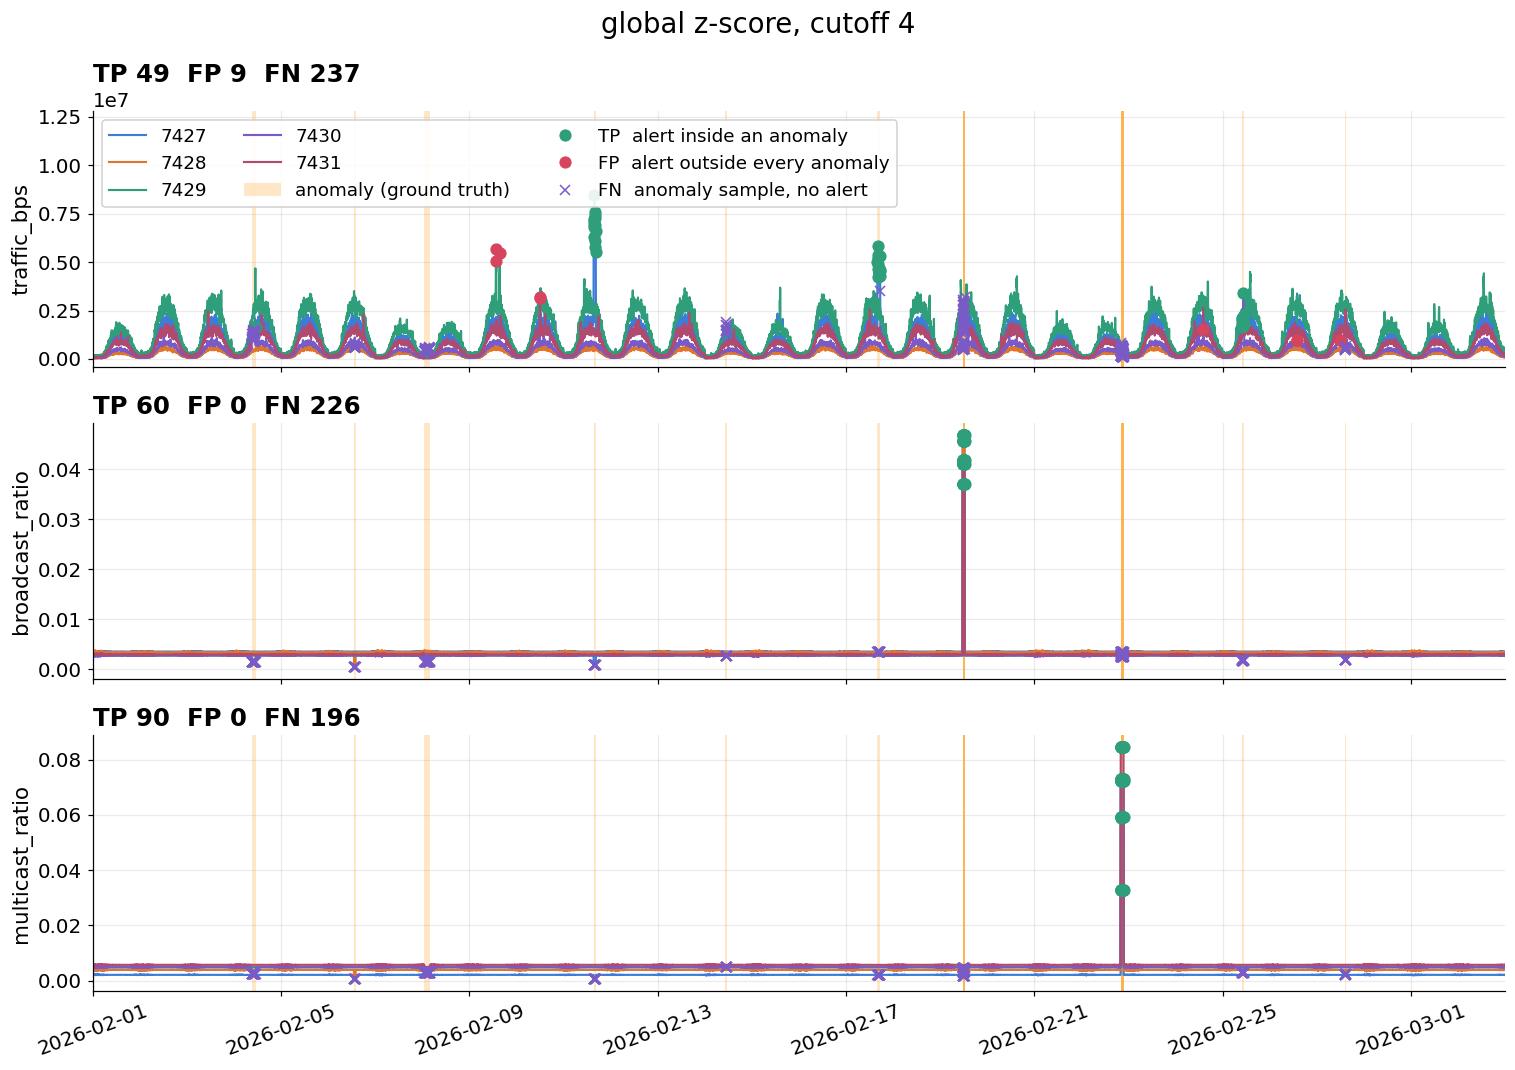

,detector,alerts,precision,anomaly_recall,delay_min,alerts_per_day
0,global z traffic_bps,58,0.845,4/18,0.0,0.3
1,global z broadcast_ratio,60,1.000,5/18,0.0,0.0
2,global z multicast_ratio,90,1.000,5/18,0.0,0.0


In [12]:
alerts_z = {c: df[f"z_{c}"] > THRESHOLD for c in COLUMNS}
plot_signals(data=df, columns=COLUMNS, ports=PORTS, events=ANOMALY_TYPES,
             alerts=alerts_z, outcomes=True, zoom=False, pad="6h",
             title=f"global z-score, cutoff {THRESHOLD:g}")
report(alerts={f"global z {c}": a for c, a in alerts_z.items()},
       data=df, ports=PORTS, events="all")

At a cutoff of 4 this looks like a success on `traffic_bps`: precise, and well under one stray
alert per day. The question is what it took to get there.

In [13]:
report(alerts={f"global z traffic_bps > {t}": df["z_traffic_bps"] > t
               for t in (2, 2.5, 3, 4, 5)},
       data=df, ports=PORTS, events="all")

,detector,alerts,precision,anomaly_recall,delay_min,alerts_per_day
0,global z traffic_bps > 2,616,0.138,9/18,0.0,17.70
1,global z traffic_bps > 2.5,202,0.351,5/18,0.0,4.37
2,global z traffic_bps > 3,122,0.516,5/18,0.0,1.97
3,global z traffic_bps > 4,58,0.845,4/18,0.0,0.30
4,global z traffic_bps > 5,39,0.974,3/18,0.0,0.03


That is the actual failure, and it is a narrow operating range rather than an outright miss. The
cutoff has to be 4 or above to stay precise. Drop it to 3 and precision halves; drop it to 2 and
it falls to 0.14 with almost 7 stray alerts a day, while anomaly recall gains one window.

The reason is the denominator. One standard deviation over thirty days is inflated by the daily
and weekly cycle, so a deviation smaller than a daily peak cannot reach a usable cutoff at all.
The score is not wrong; it simply cannot resolve anything below the scale of the cycle. Step 8
checks the assumptions behind it, and Step 9 replaces the baseline.

## Step 8 — What the z-score assumed

**Normality**, which is what lets a cutoff of 3 mean "0.13% of samples", and **unimodality**,
which is what lets one mean and one standard deviation describe the data at all. Both checkable,
both false here.

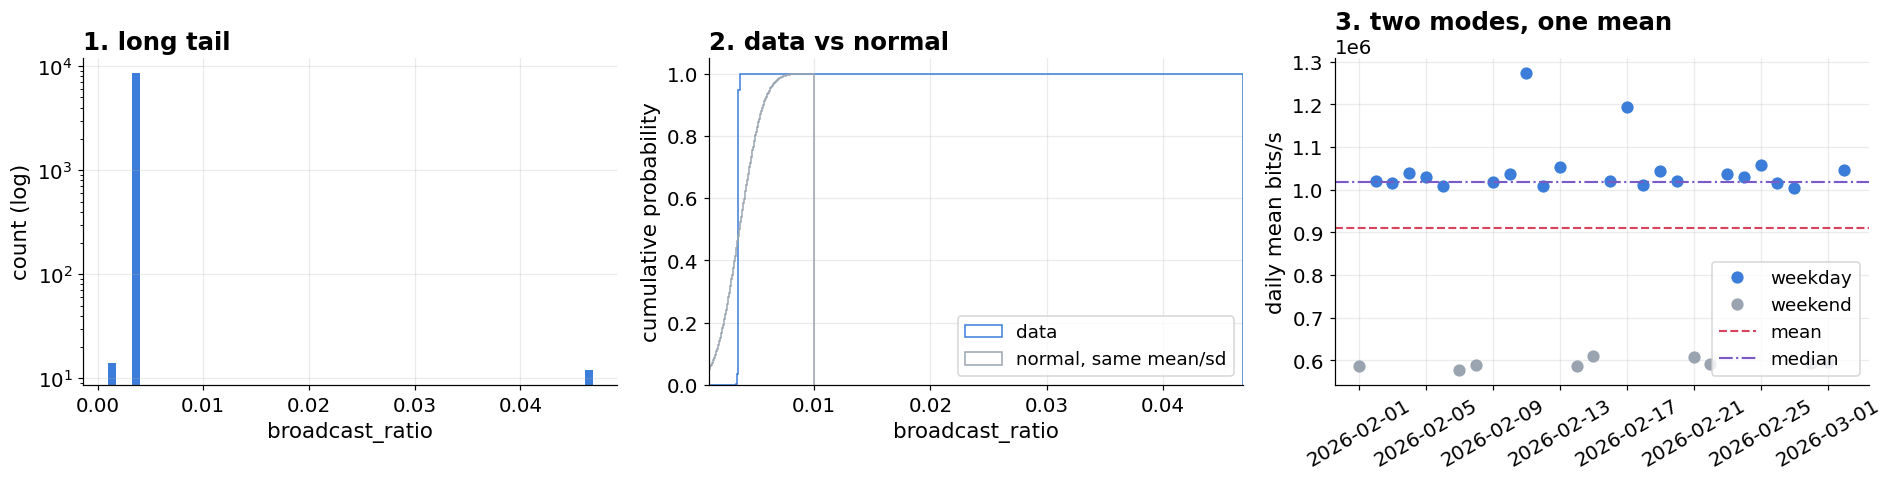

Shapiro-Wilk on broadcast_ratio (n=1000): W=0.0279, p=3.43e-57
daily traffic: sd 2.148e+05 is 6.1x the robust scale; mean 9.105e+05 vs median 1.017e+06


In [14]:
col, port = "broadcast_ratio", PORTS[0]
v = df.loc[df["port_id"] == port, col]

daily = (df[df["port_id"] == port]
         .assign(date=lambda d: d["timestamp"].dt.floor("D"))
         .groupby("date", as_index=False)["traffic_bps"].mean())
daily["weekend"] = daily["date"].dt.dayofweek >= 5

w, h = plt.rcParams["figure.figsize"]
fig, axes = plt.subplots(1, 3, figsize=(w * 1.25, h))
axes[0].hist(v, bins=60, color=C["signal"])
axes[0].set(yscale="log", xlabel=col, ylabel="count (log)", title="1. long tail")

axes[1].hist(v, bins=400, density=True, histtype="step", cumulative=True,
             color=C["signal"], label="data")
axes[1].hist(np.random.default_rng(0).normal(v.mean(), v.std(ddof=0), 20_000),
             bins=400, density=True, histtype="step", cumulative=True,
             color=C["muted"], label="normal, same mean/sd")
axes[1].set(xlim=(v.min(), v.quantile(0.9995)), xlabel=col,
            ylabel="cumulative probability", title="2. data vs normal")
axes[1].legend(loc="lower right")

for lab, sel, c in [("weekday", ~daily["weekend"], C["signal"]),
                    ("weekend", daily["weekend"], C["muted"])]:
    axes[2].plot(daily.loc[sel, "date"], daily.loc[sel, "traffic_bps"], "o", color=c, label=lab)
axes[2].axhline(daily["traffic_bps"].mean(), color=C["alert"], ls="--", label="mean")
axes[2].axhline(daily["traffic_bps"].median(), color=C["score"], ls="-.", label="median")
axes[2].set(ylabel="daily mean bits/s", title="3. two modes, one mean")
axes[2].tick_params(axis="x", labelrotation=30)
axes[2].legend()
plt.show()

stat, p = ss.shapiro(v.sample(1000, random_state=0))
sd = daily["traffic_bps"].std(ddof=0)
mad = 1.4826 * np.median(np.abs(daily["traffic_bps"] - daily["traffic_bps"].median()))
print(f"Shapiro-Wilk on {col} (n=1000): W={stat:.4f}, p={p:.2e}")
print(f"daily traffic: sd {sd:.3e} is {sd / mad:.1f}x the robust scale; "
      f"mean {daily['traffic_bps'].mean():.3e} vs median {daily['traffic_bps'].median():.3e}")

Panel 3 is the one that matters operationally. Nine weekend days sit near 5.9e5 bits/s and
twenty-one weekdays near 1.02e6. One mean describes neither, and the gap between the clusters
inflates the standard deviation to six times the robust scale. The denominator of every global
z-score on this port is built from a pattern that is not an anomaly at all.

The fix is not a better statistic. It is a **closer baseline**.

## Step 9 — Baseline 3: a rolling window, and the window is a hyperparameter

Stop comparing a sample to the whole month and compare it to the recent past:

$$z_t = \frac{x_t - \mathrm{mean}(x_{t-w \ldots t-1})}{\mathrm{sd}(x_{t-w \ldots t-1})}$$

The window `w` is now the most consequential number in the detector, and it fails at both ends:

- **too short** — the baseline is noisy, and worse, a sustained event enters the window and drags
  the baseline up with it. The detector ends up comparing the anomaly against itself.
- **too long** — the baseline reacts slowly to a legitimate level change, and on a cyclic signal
  it goes back to averaging night together with day.

Both are visible rather than theoretical. Take them one at a time.

In [15]:
def rolling_baseline(data, col, window=None, kind="mean", ports=None, lag=1):
    """Per-port rolling centre and scale, and the score they produce.

    `lag` shifts the window back so the baseline is built strictly from earlier samples. lag=0
    lets the current sample into its own baseline, which is a small but real self-contamination;
    lag=1 is honest and is also what an online detector can compute.

    kind="mean" uses mean and standard deviation, kind="robust" uses median and MAD.
    Returns (centre, scale, score), each aligned to `data`.
    """
    window = WINDOW if window is None else window
    ports = data["port_id"].unique() if (ports or "all") == "all" else ports
    centre = pd.Series(np.nan, index=data.index)
    scale = pd.Series(np.nan, index=data.index)
    min_p = max(3, window // 3)

    for pid in ports:
        g = data.loc[data["port_id"] == pid].sort_values("timestamp")
        v = g[col].shift(lag)
        if kind == "mean":
            c = v.rolling(window, min_periods=min_p).mean()
            s = v.rolling(window, min_periods=min_p).std()
        else:
            c = v.rolling(window, min_periods=min_p).median()
            s = (v - c).abs().rolling(window, min_periods=min_p).median() * 1.4826
        centre.loc[g.index], scale.loc[g.index] = c, s

    # A quiet stretch drives the scale toward zero, and then every ordinary wobble divides into a
    # huge score. Floor it at a fraction of the column's own spread over the whole history.
    whole = data[col].to_numpy(dtype=float)
    floor = max(0.05 * 1.4826 * np.median(np.abs(whole - np.median(whole))), 1e-12)
    score = ((data[col] - centre) / scale.fillna(floor).clip(lower=floor)).clip(-50, 50)
    return centre, scale, score

### 9a — Too short, and the event contaminates its own baseline

Event G is a broadcast storm lasting 12 samples, one hour. Draw the rolling mean baseline over
that hour for a 1-hour window and for a 12-hour window.

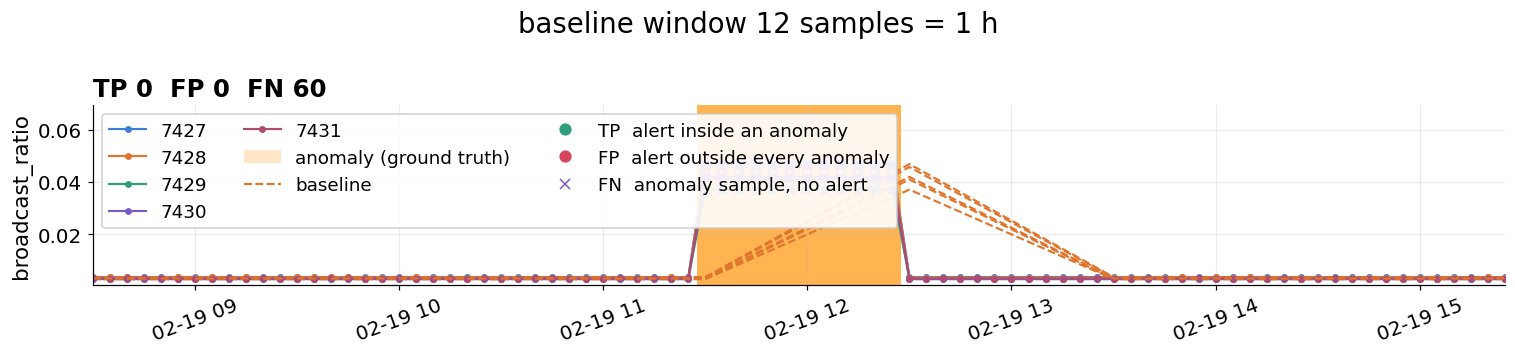

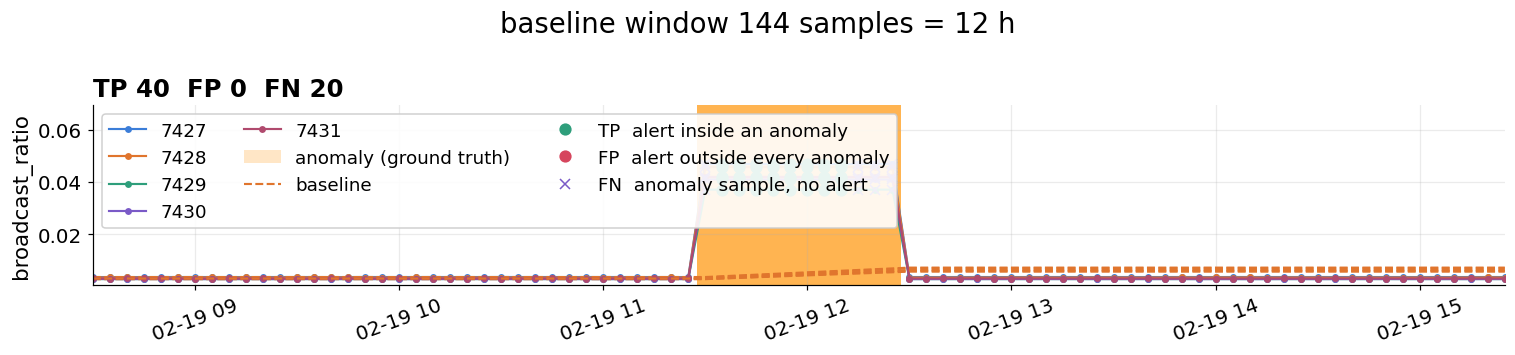

In [16]:
for w in (12, 144):
    centre, scale, score = rolling_baseline(
        data=df, col="broadcast_ratio", window=w, kind="mean", ports=PORTS, lag=1)
    plot_signals(data=df, columns=["broadcast_ratio"], ports=PORTS,
                 events=["broadcast_storm"], pad="3h", zoom=True,
                 baselines={"broadcast_ratio": centre},
                 alerts={"broadcast_ratio": confirm(breach=score > THRESHOLD, data=df, n=N_CONSEC)},
                 outcomes=True,
                 title=f"baseline window {w} samples = {w * CADENCE / 3600:.0f} h")

Compare the two figures on one thing: **the first has no red dots at all.**

With a 1-hour window the dashed baseline climbs steeply from the moment the storm starts, because
within a few samples most of the window *is* the storm. The gap between signal and baseline never
grows enough to clear the cutoff, so a storm that is fourteen times the normal level produces no
alert. The baseline then keeps rising for an hour *after* the anomaly ends, while storm samples are
still inside the window, leaving a trailing hour in which a second anomaly would also be invisible.

With a 12-hour window the baseline stays flat, and the alerts run through the event. They begin
one sample late, which is the `N_CONSEC = 2` confirmation from Step 11 being paid for in advance.

This is why a robust centre matters more at short windows than at long ones. A median needs more
than half the window contaminated before it moves; a mean starts moving on the first sample.

### 9b — Smoothing dilutes short anomalies

The same tradeoff appears in plain smoothing. A longer moving average is a cleaner line and a
smaller peak.

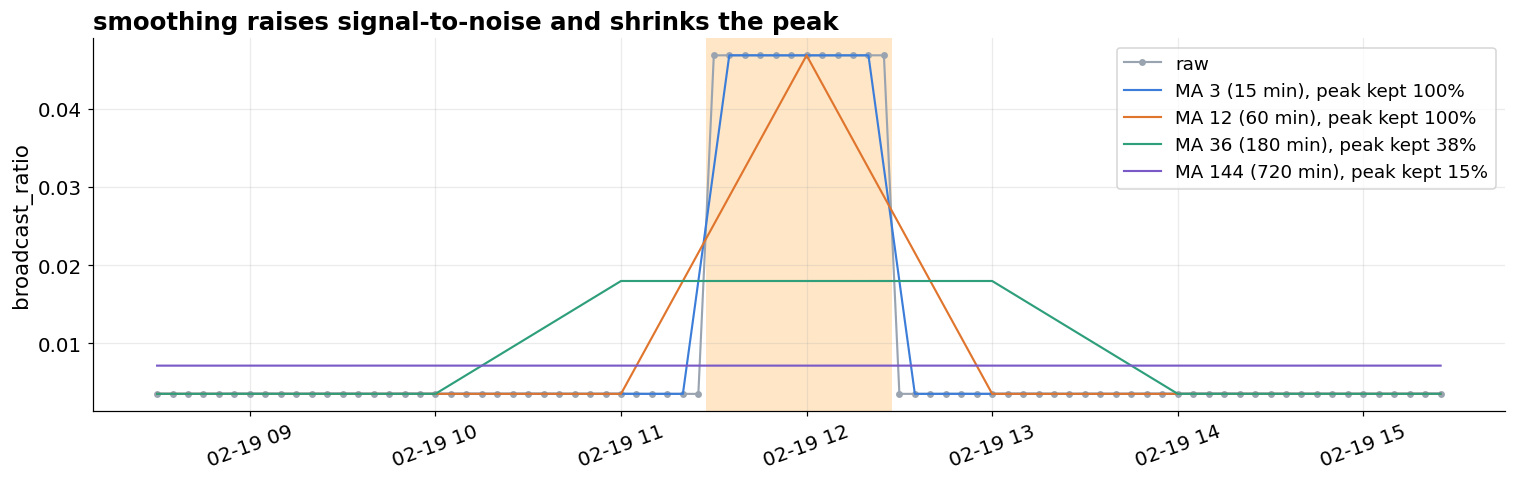

In [17]:
g = df[df["port_id"] == PORTS[0]]
win = anomaly_windows(g, ["broadcast_storm"], [PORTS[0]])
lo, hi = win["start"].min(), win["end"].max()
view = g["timestamp"].between(lo - pd.Timedelta("3h"), hi + pd.Timedelta("3h"))
peak = g.loc[g["timestamp"].between(lo, hi), "broadcast_ratio"].max()

fig, ax = plt.subplots()
ax.plot(g.loc[view, "timestamp"], g.loc[view, "broadcast_ratio"], marker=".",
        color=C["muted"], label="raw")
for smooth in (3, 12, 36, 144):
    sm = g["broadcast_ratio"].rolling(smooth, center=True, min_periods=1).mean()
    kept = sm[g["timestamp"].between(lo, hi)].max() / peak
    ax.plot(g.loc[view, "timestamp"], sm[view],
            label=f"MA {smooth} ({smooth * CADENCE / 60:.0f} min), peak kept {kept:.0%}")
ax.axvspan(lo - HALF, hi + HALF, color=C["truth"], alpha=0.25, lw=0)
ax.set(ylabel="broadcast_ratio", title="smoothing raises signal-to-noise and shrinks the peak")
ax.tick_params(axis="x", labelrotation=20)
ax.legend()
plt.show()

A moving average several times longer than the anomaly keeps only a fraction of its height.
Smoothing is not free: it buys a quieter line by spending the amplitude of exactly the short
excursions you were hoping to detect. Smooth for trend and for display, not for the thing you
threshold.

### 9c — Sweep the window

Now measure it. Same threshold, same confirmation rule, one window at a time, for a mean baseline
and a robust one.

In [18]:
SWEEP = [6, 12, 24, 36, 72, 144, 288, 576, 864, 2016]     # 30 min .. 7 days

rows = []
for col in COLUMNS:
    for w in SWEEP:
        for kind in ("mean", "robust"):
            score = rolling_baseline(data=df, col=col, window=w, kind=kind,
                                     ports=PORTS, lag=1)[2]
            r = report(alerts={"x": confirm(breach=score > THRESHOLD, data=df, n=N_CONSEC)},
                       data=df, ports=PORTS, events="all").iloc[0]
            caught, total = r["anomaly_recall"].split("/")
            rows.append({"column": col, "kind": kind, "window": w,
                         "hours": round(w * CADENCE / 3600, 1),
                         "anomaly_recall": int(caught), "of": int(total),
                         "alerts_per_day": r["alerts_per_day"], "delay_min": r["delay_min"]})
sweep = pd.DataFrame(rows)
sweep.pivot_table(index=["column", "hours"], columns="kind",
                  values=["anomaly_recall", "alerts_per_day"])

alerts_per_day        anomaly_recall       
kind                            mean robust           mean robust
column          hours                                            
broadcast_ratio 0.5             0.00   0.77            0.0    5.0
                1.0             0.00   1.03            0.0    5.0
                2.0             0.07   0.57            5.0    5.0
                3.0             0.07   0.33            5.0    5.0
                6.0             0.20   1.80            5.0    5.0
                12.0            0.90   7.27            5.0    5.0
                24.0            0.13   6.93            5.0    5.0
                48.0            0.20   7.40            5.0    5.0
                72.0            0.30   7.60            5.0    5.0
                168.0           0.07   7.23            5.0    5.0
multicast_ratio 0.5             0.00   0.80            0.0    5.0
                1.0             0.00   0.63            0.0    5.0
                2.0             0.07   0.37            5.0    5.0
                3.0             0.03   0.00            5.0    5.0
                6.0             0.03   0.10            5.0    5.0
                12.0            0.10   0.40            5.0    5.0
                24.0            0.03   0.40            5.0    5.0
                48.0            0.00   0.43            5.0    5.0
                72.0            0.00   0.43            5.0    5.0
                168.0           0.00   0.43            5.0    5.0
traffic_bps     0.5             0.13   4.80            0.0    6.0
                1.0             0.30   2.57            1.0    5.0
                2.0             0.63   2.13            4.0    4.0
                3.0             0.83   1.80            4.0    3.0
                6.0             1.50  37.20            4.0    4.0
                12.0            1.03   2.97            4.0    2.0
                24.0            0.07  15.90            3.0    1.0
                48.0            0.27   5.97            3.0    3.0
                72.0            0.30  26.50            3.0    3.0
                168.0           0.07  62.21            3.0    4.0

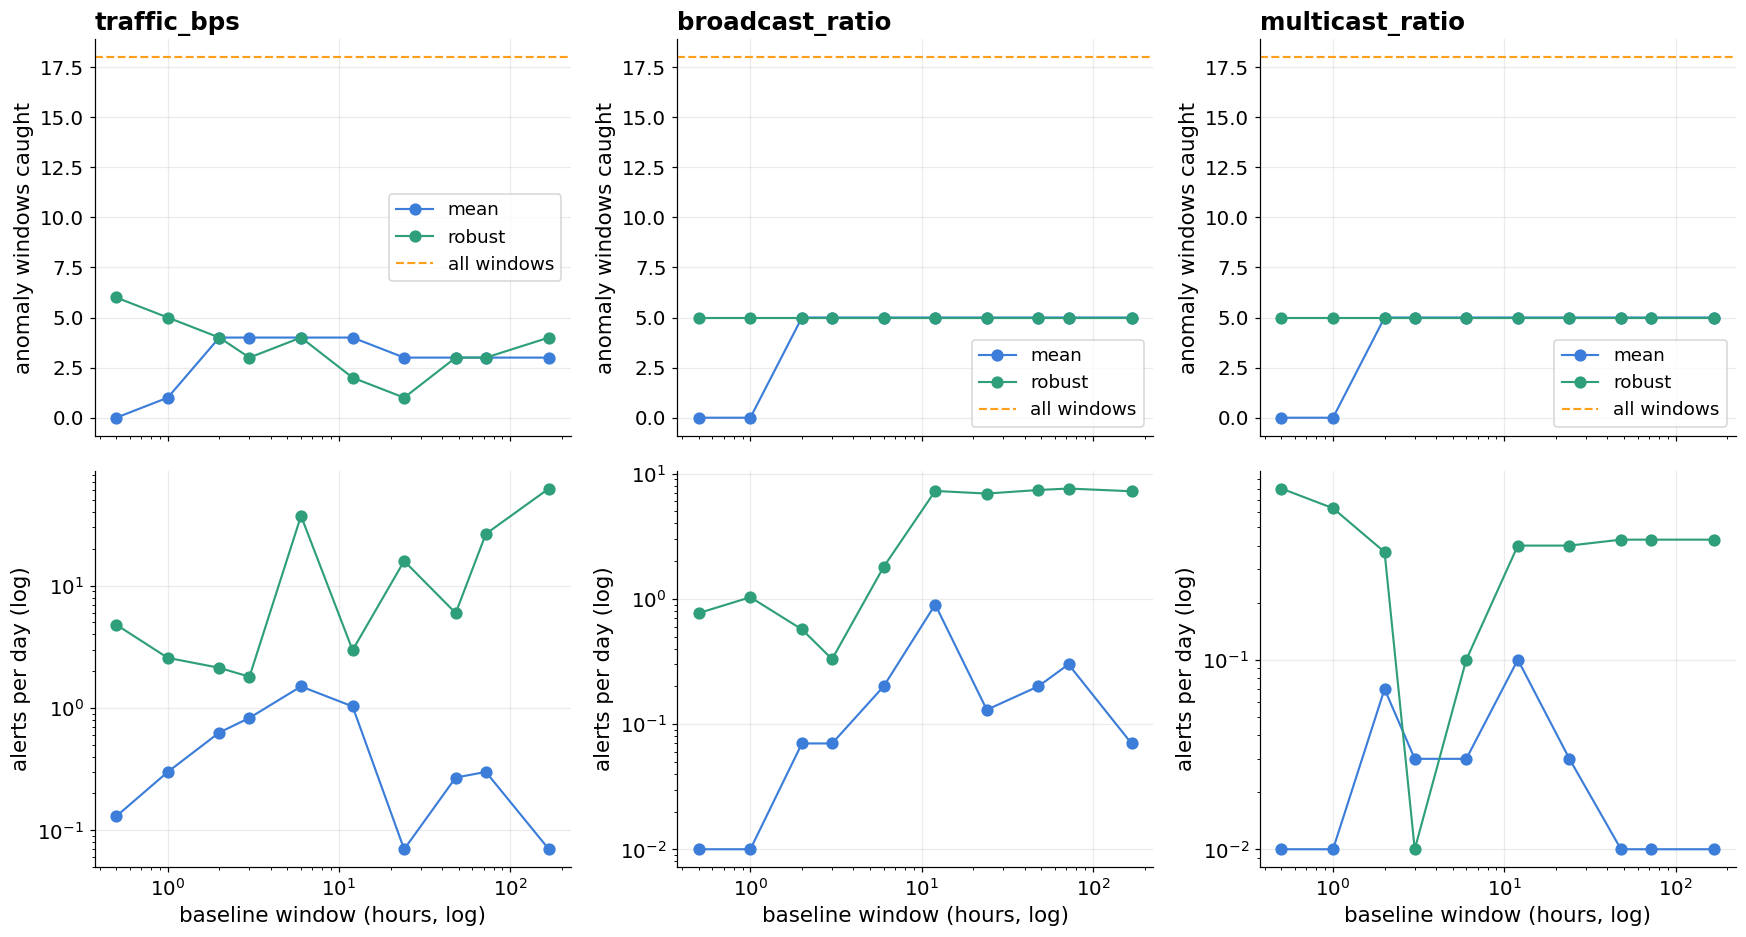

In [19]:
w, h = plt.rcParams["figure.figsize"]
fig, axes = plt.subplots(2, len(COLUMNS), figsize=(w * 1.15, h * 1.9), sharex=True)
for j, col in enumerate(COLUMNS):
    d = sweep[sweep["column"] == col]
    for kind, c in [("mean", C["signal"]), ("robust", C["peer"])]:
        k = d[d["kind"] == kind]
        axes[0, j].plot(k["hours"], k["anomaly_recall"], "-o", color=c, label=kind)
        axes[1, j].plot(k["hours"], k["alerts_per_day"].clip(lower=0.01), "-o", color=c,
                        label=kind)
    axes[0, j].axhline(d["of"].max(), color=C["truth"], ls="--", label="all windows")
    axes[0, j].set(title=col, ylabel="anomaly windows caught")
    axes[1, j].set(xscale="log", yscale="log", xlabel="baseline window (hours, log)",
                   ylabel="alerts per day (log)")
    axes[0, j].legend()
plt.show()

Three results, all of them in the table above.

**The mean baseline catches almost nothing at 30 minutes to an hour.** Zero of 18 windows on both
ratio columns at both lengths, and zero then one on `traffic_bps`. It reaches full recall only once
the window reaches two hours. That is 9a arriving as a number: below roughly twice the anomaly
duration, the baseline is made of the anomaly.

**The robust baseline holds its recall all the way down.** Five windows on the ratio columns and six
on `traffic_bps` at a 30-minute baseline, where the mean gets none. This is the whole argument for
the median, and it is specifically an argument about *short* windows and contaminated history.

**Neither is quieter everywhere, and the robust one is worse at both ends.** Its alert rate is
U-shaped on every column. `multicast_ratio` runs 0.80 alerts a day at 30 minutes, reaches 0.00 at
three hours, then settles near 0.43. `broadcast_ratio` bottoms at 0.33 around three hours and climbs
past 7 a day from twelve hours onward. `traffic_bps` reaches 62 a day at one week. Noisy at the
short end because a half-hour MAD is tiny, noisy at the long end because the window has started to
span the daily cycle it was never meant to average over. The mean baseline is quieter almost
everywhere past the contamination zone.

So the pairing matters as much as either choice. Use a robust centre when the window is short or
the history may contain incidents; a mean is fine, and quieter, when the window is long enough to
be clean and the signal has no cycle inside it.

**Rule of thumb:** several times longer than the shortest anomaly you intend to catch, and short
enough that the baseline does not span a cycle you have not removed. Between those two bounds,
sweep.

### 9d — One window is rarely enough

Different window lengths see different phenomena, so build a few on purpose instead of sweeping
for a single winner.

| scale | statistic | what it catches |
|---|---|---|
| 1 min | max, count, difference | instantaneous spikes and outages |
| 5 min | mean, sd, p95 | short service degradation |
| 1 hour | median, trend slope | slow drift and capacity pressure |
| 1 day | seasonal baseline | day/night deviation |
| 1 week | same-time comparison | weekday against weekend |

The cheapest useful combination is two: a short window against a long one. Their difference is a
level-shift signal that neither provides alone.

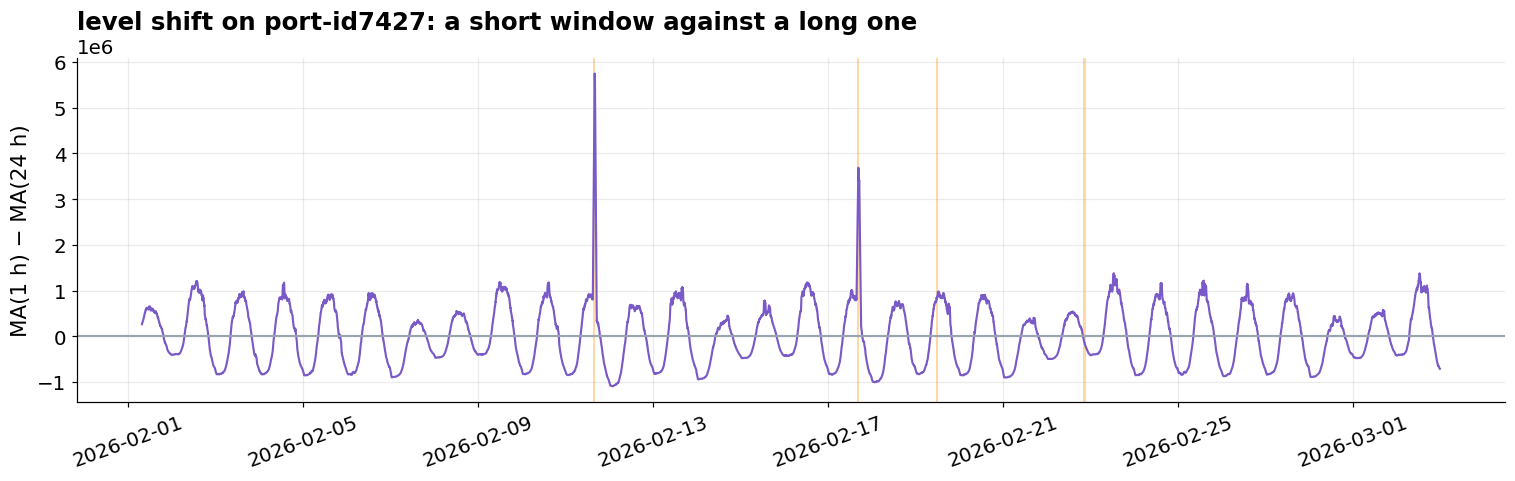

In [20]:
level = pd.Series(np.nan, index=df.index)
for pid in PORTS:
    v = df.loc[df["port_id"] == pid, "traffic_bps"]
    level.loc[v.index] = (v.rolling(12, min_periods=3).mean()
                          - v.rolling(288, min_periods=96).mean())

g = df[df["port_id"] == PORTS[0]]
fig, ax = plt.subplots()
ax.plot(g["timestamp"], level.loc[g.index], color=C["score"])
ax.axhline(0, color=C["muted"])
for e in anomaly_windows(events="all", ports=[PORTS[0]]).itertuples():
    ax.axvspan(e.start - HALF, e.end + HALF, color=C["truth"], alpha=0.4, lw=0)
ax.set(ylabel="MA(1 h) − MA(24 h)",
       title=f"level shift on {PORTS[0]}: a short window against a long one")
ax.tick_params(axis="x", labelrotation=20)
plt.show()

The trace oscillates with the daily cycle, which is expected: at 09:00 the last hour really is
above the last day. Its value is that a genuine level change pushes it away from that regular
oscillation and keeps it there, which is what a change point looks like. Lab 02 builds that
comparison properly with two adjacent windows.

Multi-scale features cost dimension and correlation, and neighbouring windows are highly
correlated by construction. Choose scales from the phenomena you need; do not enumerate.

## Step 10 — Baselines 4, 5 and 6: robust, seasonal, peer

Three more answers to "compared to what", and the third one leaves the time axis entirely.

**Robust** keeps the rolling window and swaps the mean and standard deviation for the median and the
MAD. It survives a contaminated window and fails outright when over half the samples are identical.

**Seasonal** changes the comparison set: not the last few hours, but this hour of the day across the
other days. Of all six it is the only one that cannot be contaminated by the anomaly it is testing,
however long that anomaly runs, because the comparison samples are on other days.

**Peer** compares a port against the other ports at the same instant, leaving itself out. It needs
no history at all, which makes it the only baseline here that works on a port installed this
morning. Its blind spot is the mirror image of seasonal's strength: when every peer moves together,
the peer group defines the anomaly as normal.

In [21]:
def seasonal_baseline(data, col, ports=None, by=("hour",)):
    """Centre and scale taken from the same seasonal position on other days.

    by=("hour",) compares 10:00 against every other 10:00 on that port. Adding "dayofweek"
    compares Monday 10:00 against other Mondays at 10:00, which needs several weeks of history
    before each cell holds enough samples to be worth anything.
    """
    ports = data["port_id"].unique() if (ports or "all") == "all" else ports
    keys = {"hour": data["timestamp"].dt.hour, "dayofweek": data["timestamp"].dt.dayofweek}
    grp = [data["port_id"]] + [keys[b] for b in by]
    centre = data.groupby(grp, observed=True)[col].transform("median")
    scale = ((data[col] - centre).abs().groupby(grp, observed=True).transform("median") * 1.4826)
    floor = max(0.05 * float(scale.median()), 1e-12)
    score = ((data[col] - centre) / scale.fillna(floor).clip(lower=floor)).clip(-50, 50)
    return centre, scale, score


def peer_baseline(data=df, col="traffic_bps", ports=None, min_peers=3):
    """Centre and scale from the other ports at the same timestamp, leaving this port out.

    Leave-one-out matters: including the port under test lets a large excursion pull the very median
    it is being compared against, which is the same self-contamination Step 9a showed in time.

    No history is used at all, so this is the one baseline that works on a port with no past. It
    goes blind when the whole group moves together, which is exactly what a broadcast storm does.
    `min_peers` refuses an estimate built on too few peers rather than returning a confident number.
    """
    ports = PORTS if ports is None else ports
    ports = sorted(data["port_id"].unique()) if ports == "all" else list(ports)
    wide = data[data["port_id"].isin(ports)].pivot_table(
        index="timestamp", columns="port_id", values=col, aggfunc="first")

    centre = pd.Series(np.nan, index=data.index, dtype=float)
    scale = pd.Series(np.nan, index=data.index, dtype=float)
    for pid in ports:
        peers = wide.drop(columns=[pid])                 # this is the leave-one-out
        ok = peers.notna().sum(axis=1) >= min_peers      # refuse a thin peer group
        c = peers.median(axis=1).where(ok)
        sc = peers.sub(c, axis=0).abs().median(axis=1).where(ok) * 1.4826
        rows = data.index[data["port_id"] == pid]
        t = data.loc[rows, "timestamp"]
        centre.loc[rows] = c.reindex(t).to_numpy()
        scale.loc[rows] = sc.reindex(t).to_numpy()

    floor = max(0.05 * float(np.nanmedian(scale)), 1e-12)
    score = ((data[col] - centre) / scale.fillna(floor).clip(lower=floor)).clip(-50, 50)
    return centre, scale, score


baselines = {}
for col in COLUMNS:
    baselines["rolling mean", col] = rolling_baseline(
        data=df, col=col, window=WINDOW, kind="mean", ports=PORTS, lag=1)
    baselines["rolling robust", col] = rolling_baseline(
        data=df, col=col, window=WINDOW, kind="robust", ports=PORTS, lag=1)
    baselines["seasonal", col] = seasonal_baseline(
        data=df, col=col, ports=PORTS, by=("hour",))
    baselines["peer", col] = peer_baseline(
        data=df, col=col, ports=PORTS, min_peers=3)

detectors = {f"{kind} {col}": confirm(breach=v[2] > THRESHOLD, data=df, n=N_CONSEC)
             for (kind, col), v in baselines.items()}
detectors |= {f"global z {c}": confirm(breach=df[f"z_{c}"] > THRESHOLD, data=df, n=N_CONSEC)
              for c in COLUMNS}
detectors |= {f"fixed {c}": confirm(breach=fixed_score(data=df, col=c, limit=LIMITS[c]) > 1.0,
                                    data=df, n=N_CONSEC) for c in FIXED_COLS}
report(alerts=detectors, data=df, ports=PORTS, events="all").sort_values(
    ["anomaly_recall", "alerts_per_day"], ascending=[False, True])

,detector,alerts,precision,anomaly_recall,delay_min,alerts_per_day
10,seasonal multicast_ratio,85,1.000,5/18,5.0,0.00
13,global z broadcast_ratio,55,1.000,5/18,5.0,0.00
14,global z multicast_ratio,85,1.000,5/18,5.0,0.00
16,fixed broadcast_ratio,55,1.000,5/18,5.0,0.00
17,fixed multicast_ratio,85,1.000,5/18,5.0,0.00
6,seasonal broadcast_ratio,56,0.982,5/18,5.0,0.03
8,rolling mean multicast_ratio,43,0.930,5/18,5.0,0.10
2,seasonal traffic_bps,100,0.890,5/18,5.0,0.37
9,rolling robust multicast_ratio,97,0.876,5/18,5.0,0.40
4,rolling mean broadcast_ratio,67,0.597,5/18,5.0,0.90


`anomaly_recall` is out of 7 because that is every anomaly window on these two ports, and no
single column carries all seven: a storm shows in `broadcast_ratio` and a congestion event in
`traffic_bps`. Compare detectors within a column, not across.

Within `broadcast_ratio` and `multicast_ratio` almost everything works, including the fixed
line, because those anomalies leave a narrow band by a wide margin. `traffic_bps` separates them:
the seasonal baseline holds 0.91 precision, the rolling mean drops to 0.41, and the rolling
robust baseline is the worst detector in the table at 0.07 with 1.7 stray alerts a day. A
12-hour MAD on a signal whose daily swing is larger than any of its anomalies produces a small
denominator and a large score for every afternoon.

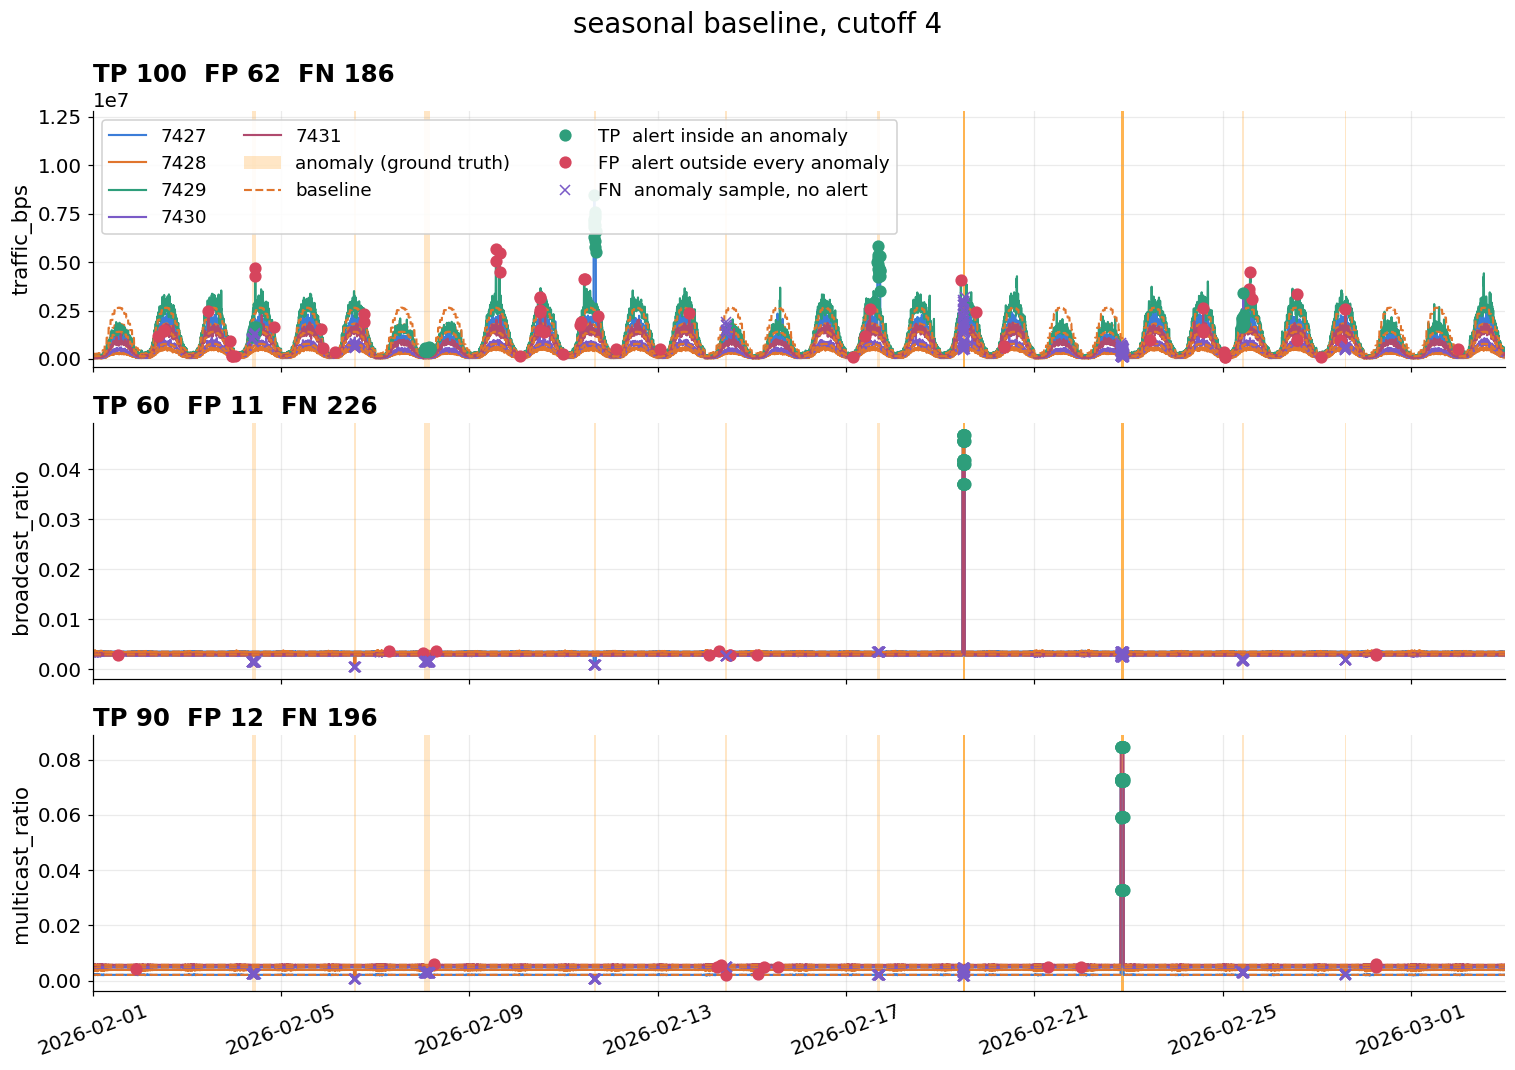

In [22]:
# Edit BASELINE_SHOWN to redraw any of the six without touching anything else.
BASELINE_SHOWN = "seasonal"        # "rolling mean" | "rolling robust" | "seasonal" | "peer"

plot_signals(data=df, columns=COLUMNS, ports=PORTS, events=ANOMALY_TYPES,
             alerts={c: baselines[BASELINE_SHOWN, c][2] > THRESHOLD for c in COLUMNS},
             baselines={c: baselines[BASELINE_SHOWN, c][0] for c in COLUMNS},
             outcomes=True, zoom=False, pad="6h",
             title=f"{BASELINE_SHOWN} baseline, cutoff {THRESHOLD:g}")

The seasonal baseline traces the daily shape instead of cutting across it, which is what the dashed
line in the top panel shows. Its risks are the ones the lecture names: it needs enough history, and
a holiday, a maintenance window or genuine business growth all shift the pattern it was built from
without being anomalies.

### The peer baseline fails here, and the reason is worth more than a success

Read the three `peer` rows. On `traffic_bps` it finds 3 windows of 18 at 0.53 precision. On
`broadcast_ratio` it emits 1,868 alerts, 61.67 a day, at 0.01 precision. On `multicast_ratio` it
emits nothing at all.

That is not a defect in the estimator, it is a precondition failing. A peer baseline assumes the
peers are comparable, and these five ports have five different roles: `wan-primary`,
`wan-secondary`, `server-uplink`, `office-vlan`, `backup-storage`. Across quiet samples their median
`broadcast_ratio` spans 1.29x and their median `multicast_ratio` spans 2.71x, which is the same
order as the deviation a real anomaly produces. The peer spread is therefore made almost entirely of
permanent structural difference between roles. Where that difference is large the MAD is wide and
nothing fires; where it is moderate every port looks permanently anomalous against the others.

The fix is not a better statistic, it is a better peer group: compare a port only against ports of
the same role, and keep this baseline for fleets where you genuinely have interchangeable members.
This dataset has exactly one port per role, so it has no peer groups at all, and finding that out
from the precision column is the reason to run it.

Peer comparison also has a blind spot no grouping fixes. Events G and H hit all five ports in the
same minute, and when every peer moves together the group redefines the anomaly as normal. Seasonal
is the mirror image: it cannot be contaminated by the anomaly it is testing, however long that
anomaly runs, because its comparison samples sit on other days. That complementarity is why the two
are worth running together rather than choosing between.

### Where the MAD breaks

Every robust method above divides by a MAD. Check that it exists before trusting it.

In [23]:
col = "discard_rate"
v = df.loc[df["port_id"] == PORTS[0], col]
z = pd.Series(ss.zscore(v, ddof=0), index=v.index)
truth = df.loc[v.index, "event_label"] != "normal"

print(f"{col} on {PORTS[0]}")
print(f"  exactly zero      {(v == 0).mean():.1%}")
print(f"  median {v.median():.6g}   MAD {np.median(np.abs(v - v.median())):.6g}")
print(f"  modified z-score  {'all NaN' if np.isnan(modified_zscore(v)).all() else 'defined'}")
print(f"  plain z > {THRESHOLD:g}     {int((z > THRESHOLD).sum())} alerts, "
      f"{int(((z > THRESHOLD) & truth).sum())} inside a labelled anomaly")

discard_rate on port-id7427
  exactly zero      91.1%
  median 0   MAD 0
  modified z-score  all NaN
  plain z > 4     43 alerts, 43 inside a labelled anomaly


About 96% of the samples are exactly zero, so the median is zero and so is the MAD. Every robust
score on this column is undefined, on a column where the plain z-score is perfect. A NaN column
and a quiet column look identical on a dashboard, so check the MAD rather than discovering this
from a silent panel.

## Step 11 — Score, label and alert are three different things

| layer | what it is | decided by |
|---|---|---|
| **anomaly score** | a continuous distance from baseline | the method |
| **anomaly label** | score above a cutoff, per sample | the threshold, versioned |
| **alert** | a label that survived persistence, severity, suppression and routing | operations |

Keeping the score continuous is what lets you re-tune later without re-running anything. Going
straight from score to notification throws that away.

Two rules turn labels into alerts here: **persistence**, `N_CONSEC` breaches in a row, and
**maintenance exclusion**, where the change calendar suppresses declared windows.

In [24]:
calendar = pd.read_csv(DATA / "change_calendar.csv", parse_dates=["start_time", "end_time"])
display(calendar[["change_id", "change_type", "scope", "start_time", "end_time", "owner"]])


def in_maintenance(data=None, cal=None):
    """True on samples covered by a declared change window, matched on port or device."""
    data = df if data is None else data
    cal = calendar if cal is None else cal
    m = pd.Series(False, index=data.index)
    for c in cal.itertuples():
        scope = (data["port_id"] == c.scope) | (data["device_id"] == c.scope)
        m |= scope & data["timestamp"].between(c.start_time, c.end_time)
    return m


MAINT = in_maintenance(data=df, cal=calendar)
print(f"{MAINT.sum():,} of {len(df):,} samples sit inside a declared change window")

,change_id,change_type,scope,start_time,end_time,owner
0,CH-01,scheduled_backup,port-id7431,2026-02-08 00:50:00,2026-02-08 04:10:00,infra-ops
1,CH-02,business_change,port-id7430,2026-02-04 08:50:00,2026-02-04 11:05:00,app-team
2,CH-03,maintenance,core-sw-01,2026-02-16 02:00:00,2026-02-16 04:00:00,network-ops
3,CH-04,maintenance,edge-fw-01,2026-02-21 03:00:00,2026-02-21 05:00:00,security-ops


169 of 43,200 samples sit inside a declared change window


In [25]:
# port-id7431 alone, because CH-01 covers a real anomaly there and the whole point of this step
# is watching the calendar remove correct alerts. Every configured column goes through all three
# layers, so the effect shows on more than one signal.
demo_port = ["port-id7431"]
layers = {}
for col in COLUMNS:
    score = seasonal_baseline(data=df, col=col, ports=demo_port, by=("hour",))[2]
    label = confirm(breach=score > THRESHOLD, data=df, n=N_CONSEC)
    layers[f"{col} | 1 breach"] = (score > THRESHOLD).fillna(False)
    layers[f"{col} | 2 label ({N_CONSEC} in a row)"] = label
    layers[f"{col} | 3 alert (maintenance excluded)"] = label & ~MAINT
report(alerts=layers, data=df, ports=demo_port, events="all")

,detector,alerts,precision,anomaly_recall,delay_min,alerts_per_day
0,traffic_bps | 1 breach,50,0.720,1/3,0.0,0.47
1,traffic_bps | 2 label (2 in a row),39,0.897,1/3,5.0,0.13
2,traffic_bps | 3 alert (maintenance excluded),4,0.000,0/3,NaN,0.13
3,broadcast_ratio | 1 breach,14,0.857,1/3,0.0,0.07
4,broadcast_ratio | 2 label (2 in a row),11,1.000,1/3,5.0,0.00
5,broadcast_ratio | 3 alert (maintenance excluded),11,1.000,1/3,5.0,0.00
6,multicast_ratio | 1 breach,21,0.857,1/3,0.0,0.10
7,multicast_ratio | 2 label (2 in a row),17,1.000,1/3,5.0,0.00
8,multicast_ratio | 3 alert (maintenance excluded),17,1.000,1/3,5.0,0.00


Both rules do visible work here.

**Persistence** takes 50 breaches down to 39 labels and lifts precision from 0.72 to 0.90. It
removes single-sample noise without touching the threshold, and it costs one sample of detection
delay, which `delay_min` prices for you. Make that trade deliberately: where the first sample
matters, `N_CONSEC = 1` with a higher cutoff may be the better pairing.

**Maintenance exclusion** bites on exactly one of the three. `traffic_bps` goes from 39 labels to
4 alerts, because 35 of them were the Sunday-night backup CH-01, which the seasonal baseline
flagged correctly since 3 a.m. traffic at that level really is unlike other nights. Its anomaly
recall drops to 0/3, and that is the right answer: the only anomaly it found was one nobody should
be woken for. The two ratio columns are untouched, because the storm and the flooding did not
happen inside a declared window.

Nothing in the telemetry separates a planned backup from an unplanned transfer. That distinction
exists only in the calendar, which is why this layer cannot be learned from the metric.

## Step 12 — The threshold is an operations decision

Lowering it catches more and pages more. Raising it does the reverse. What you are choosing
between is the cost of a missed incident and the cost of a false alarm, and neither is in the
data.

Four questions decide it, all four about the team rather than the metric: how many alerts can a
day absorb, what does one missed incident cost, is anyone available to act, and how much of the
roster is already spent on alerts.

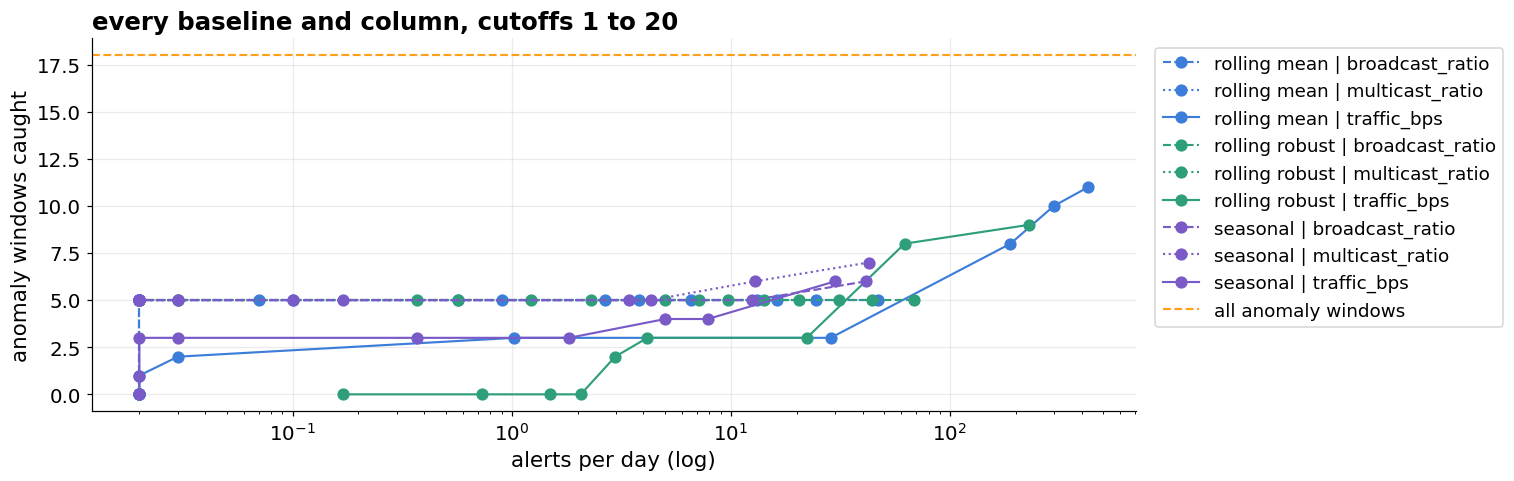

alerts_per_day                                                                                                                              caught                              \
baseline     rolling mean                              rolling robust                                    seasonal                                rolling mean                               
column    broadcast_ratio multicast_ratio traffic_bps broadcast_ratio multicast_ratio traffic_bps broadcast_ratio multicast_ratio traffic_bps broadcast_ratio multicast_ratio traffic_bps   
threshold                                                                                                                                                                                   
1.0                 46.97           16.20      428.22           68.71           20.40      229.99           41.47           42.70       29.97             5.0             5.0        11.0   
1.5                 24.60            6.60      298.40           44.37            9.70       62.27           12.53           12.93        7.87             5.0             5.0        10.0   
2.0                 13.17            2.67      189.36           31.17            5.03       22.24            3.43            4.33        5.03             5.0             5.0         8.0   
3.0                  3.83            0.57       28.60           14.13            1.23        4.17            0.17            0.10        1.83             5.0             5.0         3.0   
4.0                  0.90            0.10        1.03            7.17            0.37        2.97            0.03            0.00        0.37             5.0             5.0         3.0   
6.0                  0.07            0.00        0.03            2.30            0.03        2.07            0.00            0.00        0.03             5.0             5.0         2.0   
8.0                  0.00            0.00        0.00            0.57            0.00        1.50            0.00            0.00        0.00             5.0             5.0         1.0   
12.0                 0.00            0.00        0.00            0.03            0.00        0.73            0.00            0.00        0.00             0.0             0.0         0.0   
20.0                 0.00            0.00        0.00            0.00            0.00        0.17            0.00            0.00        0.00             0.0             0.0         0.0   

                                                                                                   
baseline   rolling robust                                    seasonal                              
column    broadcast_ratio multicast_ratio traffic_bps broadcast_ratio multicast_ratio traffic_bps  
threshold                                                                                          
1.0                   5.0             5.0         9.0             6.0             7.0         6.0  
1.5                   5.0             5.0         8.0             5.0             6.0         4.0  
2.0                   5.0             5.0         3.0             5.0             5.0         4.0  
3.0                   5.0             5.0         3.0             5.0             5.0         3.0  
4.0                   5.0             5.0         2.0             5.0             5.0         3.0  
6.0                   5.0             5.0         0.0             5.0             5.0         3.0  
8.0                   5.0             5.0         0.0             5.0             5.0         3.0  
12.0                  5.0             5.0         0.0             5.0             5.0         1.0  
20.0                  5.0             5.0         0.0             5.0             5.0         0.0

In [26]:
GRID = [1, 1.5, 2, 3, 4, 6, 8, 12, 20]

rows = []
for kind in ("rolling mean", "rolling robust", "seasonal"):
    for col in COLUMNS:
        score = baselines[kind, col][2]
        for t in GRID:
            r = report(alerts={"x": confirm(breach=score > t, data=df, n=N_CONSEC) & ~MAINT},
                       data=df, ports=PORTS, events="all").iloc[0]
            caught, total = r["anomaly_recall"].split("/")
            rows.append({"baseline": kind, "column": col, "threshold": t,
                         "alerts": r["alerts"], "caught": int(caught), "of": int(total),
                         "alerts_per_day": r["alerts_per_day"], "delay_min": r["delay_min"]})
grid = pd.DataFrame(rows)

kinds = ["rolling mean", "rolling robust", "seasonal"]
fig, ax = plt.subplots()
for (kind, col), d in grid.groupby(["baseline", "column"]):
    ax.plot(d["alerts_per_day"].clip(lower=0.02), d["caught"], marker="o",
            color=BASELINE_C[kinds.index(kind)], ls=COLUMN_LS[COLUMNS.index(col)],
            label=f"{kind} | {col}")
ax.axhline(grid["of"].max(), color=C["truth"], ls="--", label="all anomaly windows")
ax.set(xscale="log", xlabel="alerts per day (log)", ylabel="anomaly windows caught",
       title=f"every baseline and column, cutoffs {GRID[0]:g} to {GRID[-1]:g}")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.show()

grid.pivot_table(index="threshold", columns=["baseline", "column"],
                 values=["caught", "alerts_per_day"])

Each curve is one baseline on one column traced across nine cutoffs, and up-and-to-the-left is
better. Colour is the baseline, dash pattern is the column. Three things fall out that no single
number would have shown.

**Some curves are flat, and loosening them buys nothing at all.** `rolling mean | broadcast_ratio`
holds exactly 5 of 18 windows at every cutoff from 8 down to 1, while its alert rate climbs from
0.00 to 46.97 a day. Forty-seven alerts a day bought zero additional windows. A flat curve is the
clearest signal a notebook can give you that the cutoff is not the parameter to tune, and that this
column cannot express the other thirteen anomalies at any sensitivity.

**Other curves are steep, and they cross the flat ones.** `traffic_bps` sits below the ratio columns
at every strict cutoff and then overtakes them: 1 window of 18 at cutoff 8, 3 at cutoff 3, 8 at
cutoff 2, 11 at cutoff 1. The price runs 0.00, 28.60, 189.36 and 428.22 alerts a day, so the last
three windows cost more than the previous eight. "Which baseline is best" has no answer until the
alert budget is fixed, and a comparison at one cutoff is not a comparison.

**No curve reaches 18.** The dashed line is every anomaly window on the fleet, and no single
column carries every anomaly type: a storm lives in `broadcast_ratio` and a congestion event in
`traffic_bps`. The ceiling here is set by the signal, not by the threshold, and no amount of
loosening fixes a column that cannot express the failure. That is the argument for scoring several
signals rather than tuning one.

Note which numbers this lab reports and which it does not. Accuracy is absent on purpose: with
226 anomaly samples in 43,200, a detector that alerts on nothing scores over 99%. Precision,
event-level recall, detection delay and alerts per day each answer a question somebody asks.

## Exercises

Two tiers. The first six are measurements: change one thing, re-run, read the figure. The last four
have no answer in this notebook, because they need what you know about your own network.

### Measure it

1. **Window.** Set `WINDOW = 12` (1 h) and re-run Step 10. Which baselines lose recall, and does
   Step 9a explain which ones survive? Then set `WINDOW = 2016` (7 days) and explain the alert rate
   from the sweep in 9c rather than from the new table.
2. **Cutoff.** Set `THRESHOLD` to `2.0`, then `8.0`. Whose alerts per day grows fastest, and did the
   ranked plot in Step 7 predict it?
3. **Persistence.** Set `N_CONSEC` to `1`, then `4`, and compare the three layers in Step 11. How
   many minutes of detection delay did each sample of confirmation cost, and at what value of
   `N_CONSEC` does the 8-sample event become structurally impossible to catch?
4. **Degenerate columns.** Put `"errors_pps"` into `COLUMNS` and re-run Step 10. Every rolling and
   seasonal baseline on it will be NaN or nonsense. Before you run it, predict which of the six
   baselines still returns a usable number, then check.
5. **Peer group.** In `peer_baseline`, raise `min_peers` to `4`. With five ports that leaves no
   margin. Then restrict `PORTS` to the two `edge-fw-01` ports and re-run: is a peer group of two
   worth anything, and what does the `precision` column say?
6. **Seasonal depth.** Call `seasonal_baseline` with `by=("hour", "dayofweek")`. With 30 days that is
   four samples per cell. Compare against `by=("hour",)` on both recall and alerts per day, and
   decide whether the extra resolution paid for the thinner cells.

### Design it

These are the questions this lab cannot answer for you. Write the answer down before you code it,
and be specific about the network you actually operate.

7. **Name your own baseline source.** Step 3 lists seven places a baseline can come from. For one
   metric you personally watch, write which of the seven you use today, and which one you would
   use if you had to justify it in a post-incident review. If those differ, say what stops you
   switching. The gap is usually history depth or a missing topology map, and both are fixable.

8. **Price a miss against a page.** Step 12 refuses to pick a threshold because the cost is not in
   the data. Put numbers on it for one service you support: what does one missed incident cost, in
   minutes of outage or in whatever your organisation counts, and what does one unnecessary page
   cost at 03:00? Now find the point on the Step 12 plane those two numbers imply. Most teams
   discover the ratio they have been implicitly assuming is off by an order of magnitude.

9. **Design the suppression list you actually need.** Step 11 suppresses declared change windows.
   Real suppression has at least two more kinds: a known-broken exporter, where the data cannot be
   trusted, and a permanently noisy interface nobody will fix. Write the schema for a suppression
   record covering all three, and say for each field who is responsible for keeping it current. Then
   answer the question that decides whether it survives: what makes an entry expire?

10. **Choose the metric that would have caught your last incident.** Take one real incident you
    remember. Which of the thirteen features here, or which feature you would have to add, moves
    first during it? Add that feature to Step 2, put it in `COLUMNS`, pick the baseline from your
    answer to exercise 7, and see what recall and alerts per day it buys on this dataset. The
    dataset is synthetic and the answer will not transfer, but the reasoning does, and the shape of
    the argument is what you take back to work.

In [27]:
# YOUR CODE HERE

## Summary

**No baseline, no anomaly.** Five here, each answering "compared to what" differently: a fixed
line, the whole month, the last `w` samples, the last `w` samples robustly, and the same hour on
other days. None dominates, and a fixed threshold still beats every adaptive method on a signal
with a hard limit.

**The window is a hyperparameter, not a default.** Too short and a sustained event walks into its
own baseline, which cost the mean baseline nearly all of its recall at 30 minutes. Too long and
the baseline spans the cycle it was meant to avoid, and the alert rate climbs. Sweep it against
anomaly recall and alerts per day, and expect a different answer per signal.

**Smoothing is not detection.** A longer moving average keeps a shrinking fraction of a short
event's amplitude. Use it for trend and for display, not for the thing you threshold.

**Score, label and alert are three layers.** Persistence and a maintenance calendar sit between
the last two, and each removes alerts that a threshold alone cannot.

**The threshold is priced in on-call hours.** Report precision, anomaly recall, detection delay and
alerts per day, then choose the point on that curve the team can actually staff.

Every score here still compares a sample to its own port's past. Lab 02 asks what happens when
the anomaly is only anomalous **in context**, and what a model does when you hand it a window
instead of a number.